<a href="https://colab.research.google.com/github/MarcelinaBytes/readmission-prediction-ML/blob/main/notebooks/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA (Exploratory Data Analysis)

In [4]:
#Clone my repo

# Move to /content
%cd /content

# Clone your repo (public!)
!git clone https://github.com/MarcelinaBytes/readmission-prediction-ML.git

# Move into repo root
%cd /content/readmission-prediction-ML

import os
os.getcwd()


/content
Cloning into 'readmission-prediction-ML'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 141 (delta 64), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 5.16 MiB | 3.46 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/readmission-prediction-ML


'/content/readmission-prediction-ML'

In [5]:
import pandas as pd

df = pd.read_csv('data/processed/clean_step1.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_flag
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

##Peek at the data

In [12]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_flag
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

In [14]:
df.describe(include='all')

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_flag
count,1.017660e+05,1.017660e+05,99493,101766,101766,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766.000000
unique,NaN,NaN,5,3,10,NaN,NaN,NaN,NaN,NaN,...,4,4,2,2,2,2,2,2,3,NaN
top,NaN,NaN,Caucasian,Female,[70-80),NaN,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,NaN
freq,NaN,NaN,76099,54708,26068,NaN,NaN,NaN,NaN,NaN,...,47383,101060,101753,101765,101764,101765,54755,78363,54864,NaN
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,2.024006,3.715642,5.754437,4.395987,43.095641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.111599
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,1.445403,5.280166,4.064081,2.985108,19.674362,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.314874
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,31.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,44.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,57.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


##Target Variable Exploration

In [ ]:
#Class Balance- critical for choosing evaluation metrics

In [15]:
target_counts = df["readmitted_flag"].value_counts()
target_counts

,count
readmitted_flag,
0,90409
1,11357


/tmp/ipykernel_448/3775860604.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="readmitted_flag", palette="viridis")


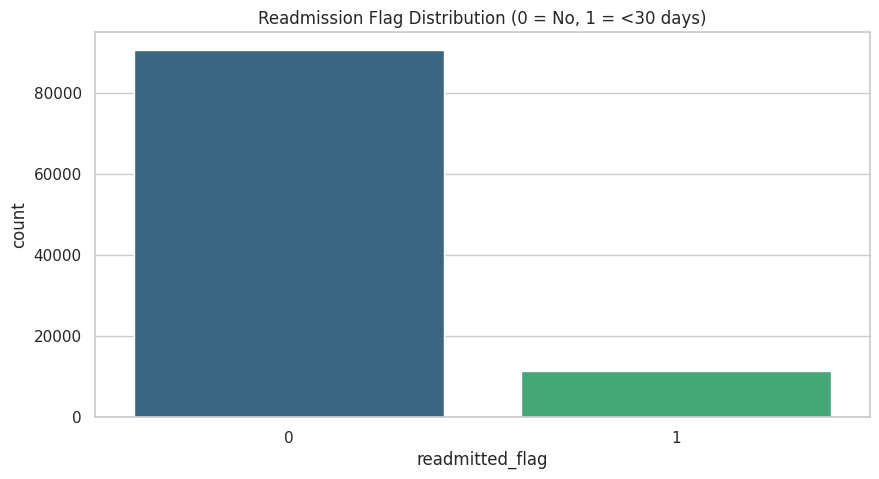

In [16]:
sns.countplot(data=df, x="readmitted_flag", palette="viridis")
plt.title("Readmission Flag Distribution (0 = No, 1 = <30 days)")
plt.show()

Numeric Feature Exploration

In [17]:
#Select numeric columns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["readmitted_flag"]]
numeric_cols

['encounter_id',
 'patient_nbr',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']

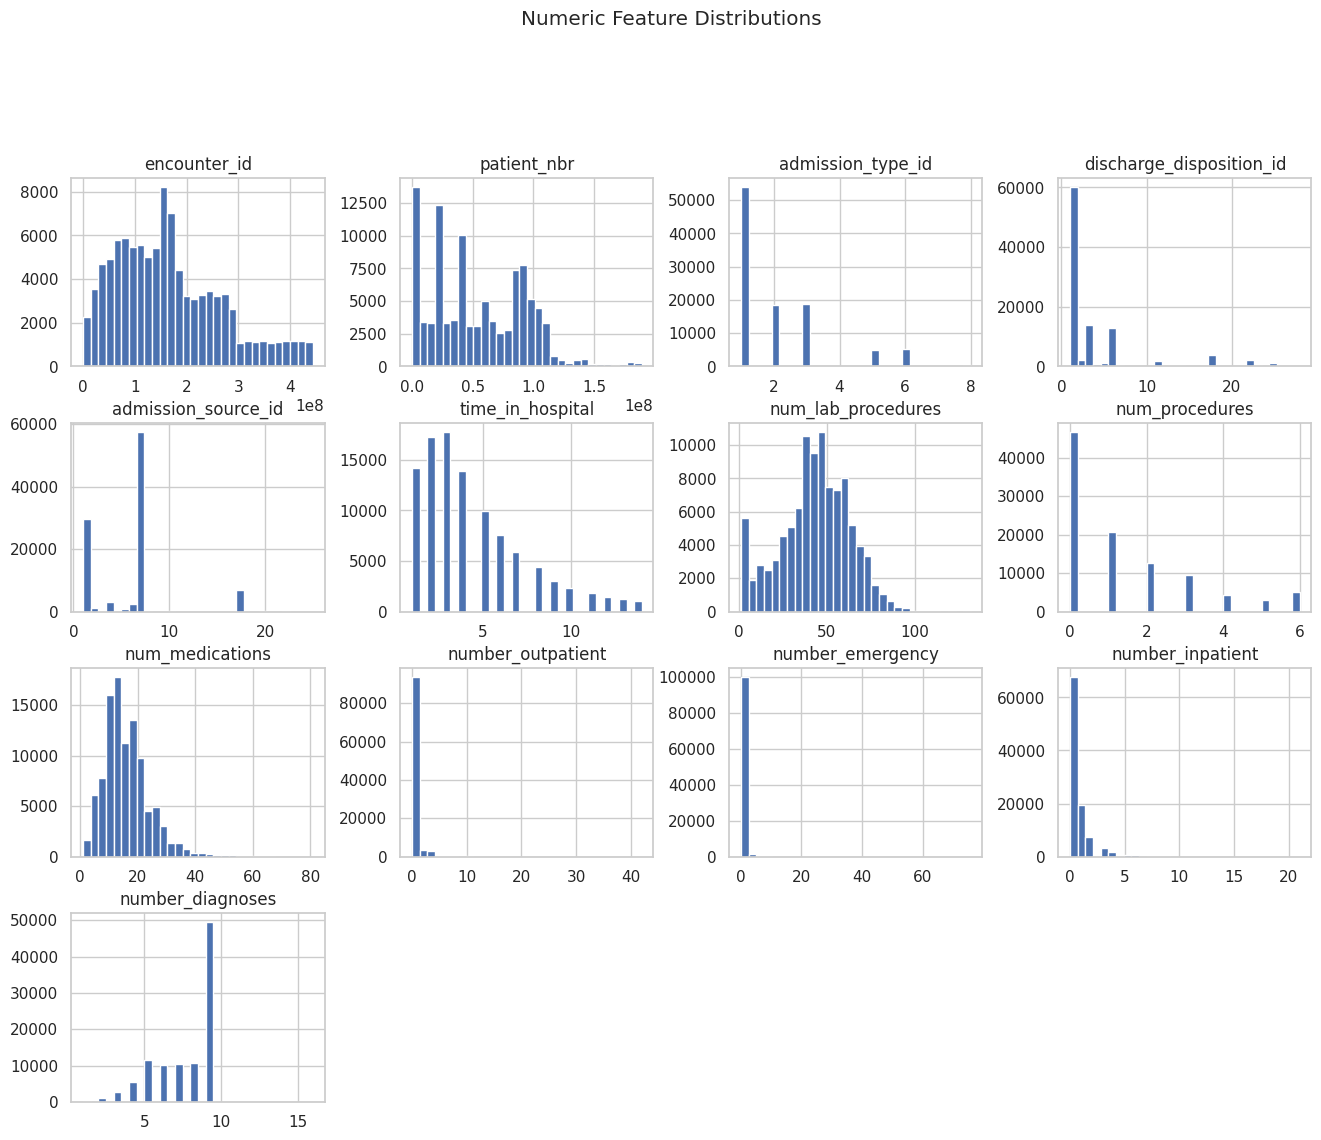

In [18]:
#Distribution Plots (histograms)

df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.show()

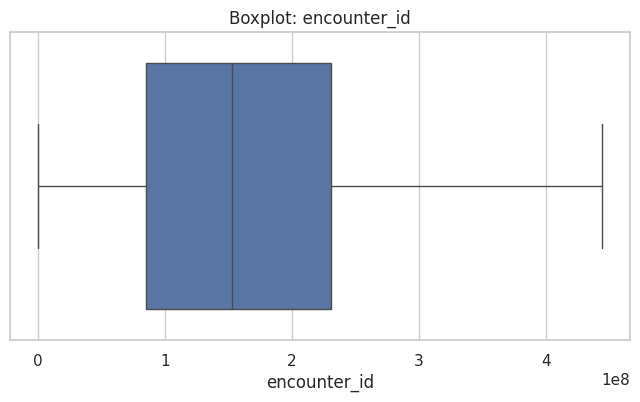

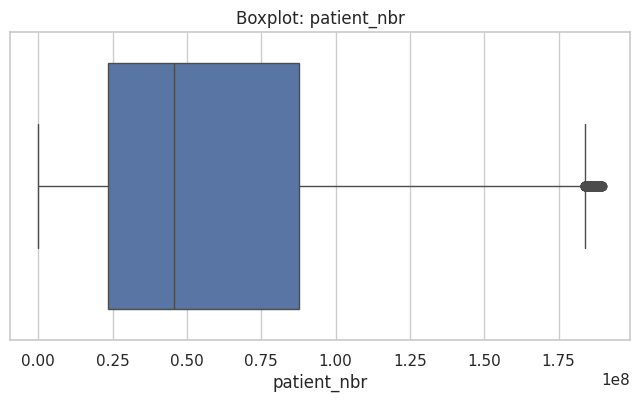

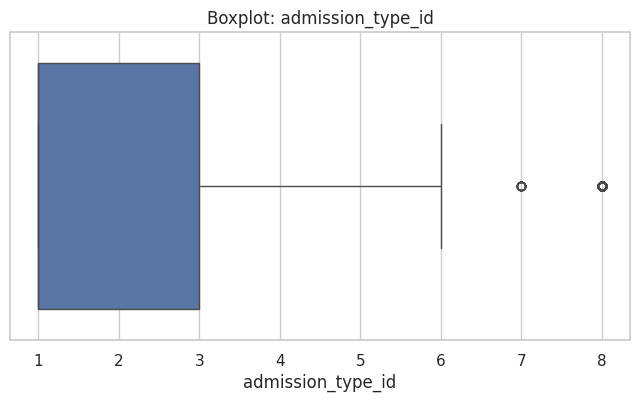

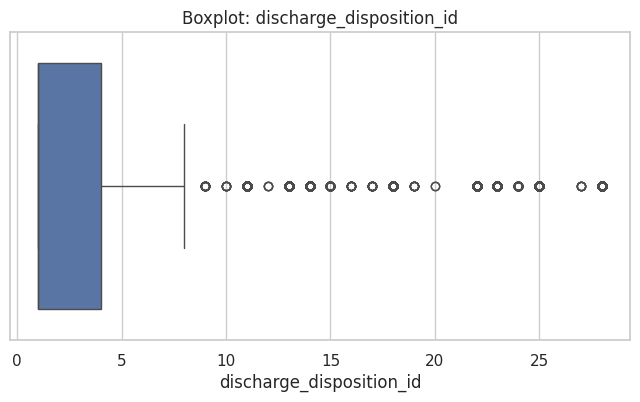

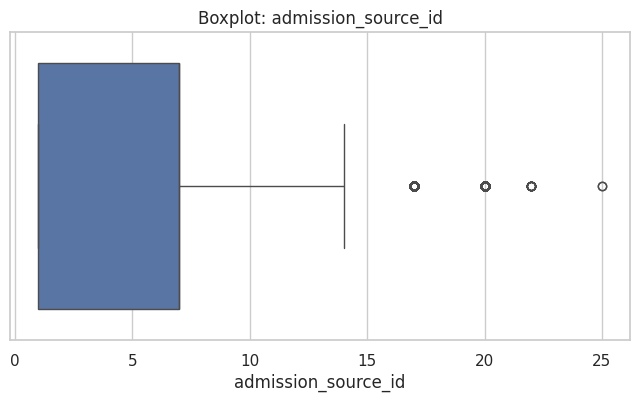

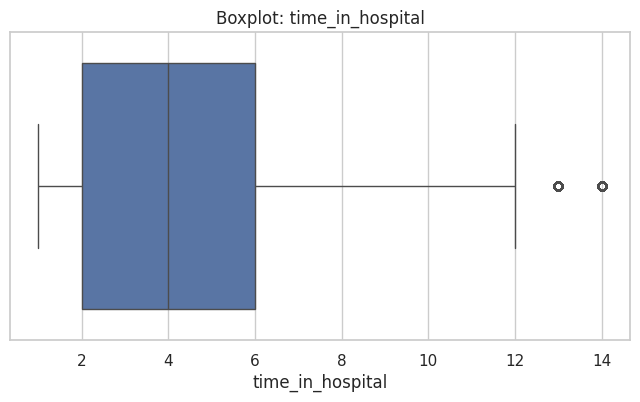

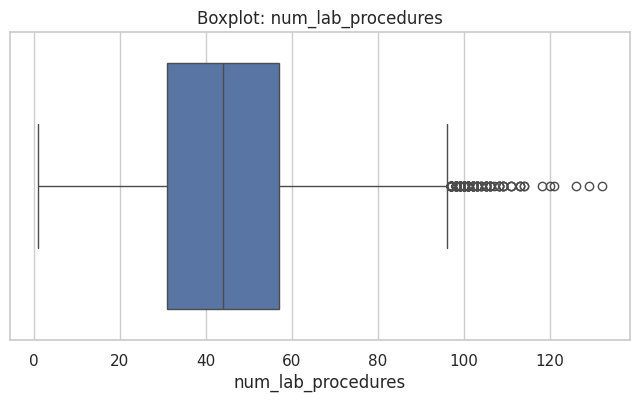

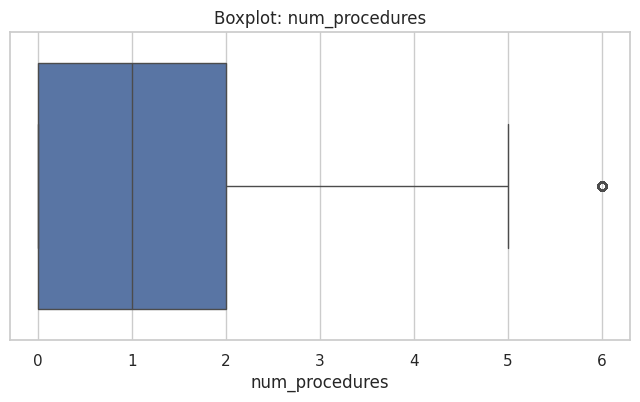

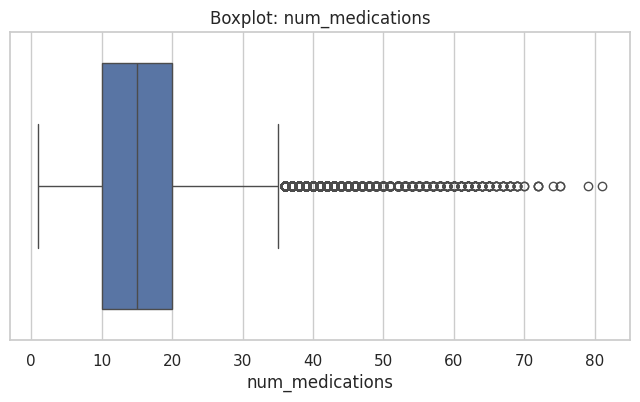

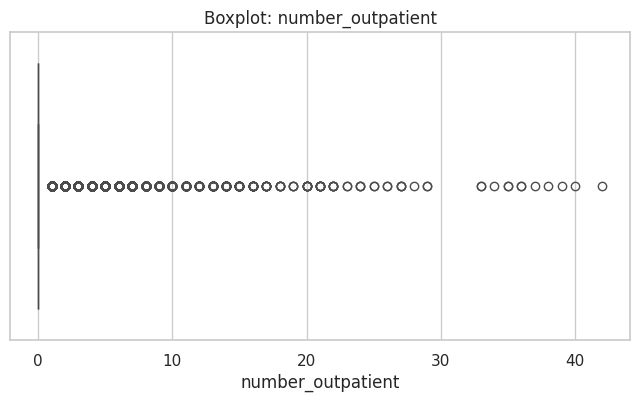

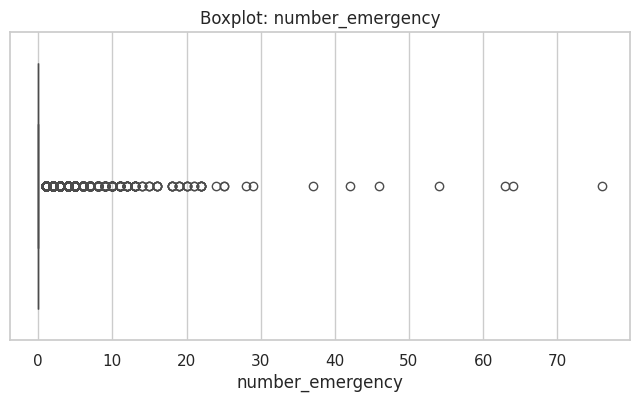

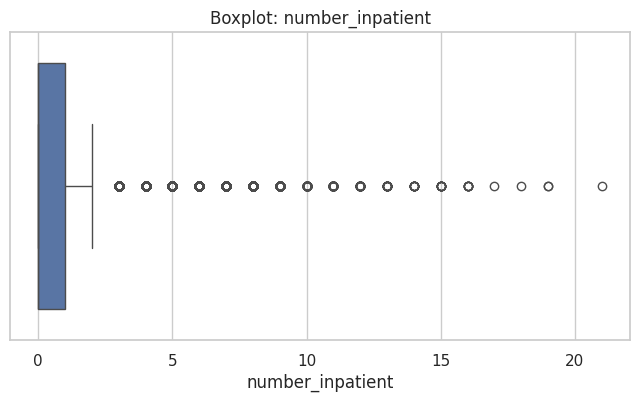

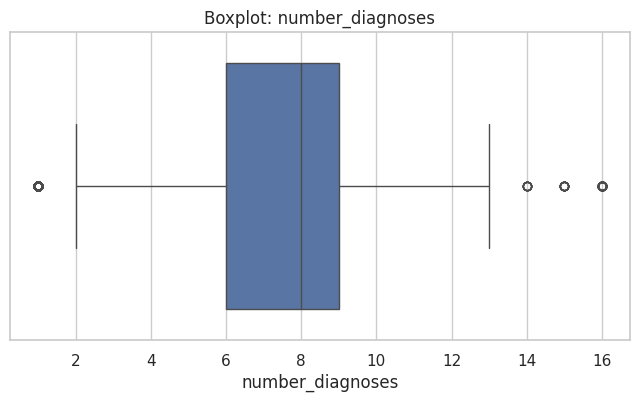

In [19]:
#Boxplots for Outliers

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

Section: Categorical Feature Exploration

In [21]:
#Identify categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove ID-like columns if they still exist
categorical_cols = [c for c in categorical_cols if c not in ['encounter_id', 'patient_nbr']]
categorical_cols


['race',
 'gender',
 'age',
 'diag_1',
 'diag_2',
 'diag_3',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


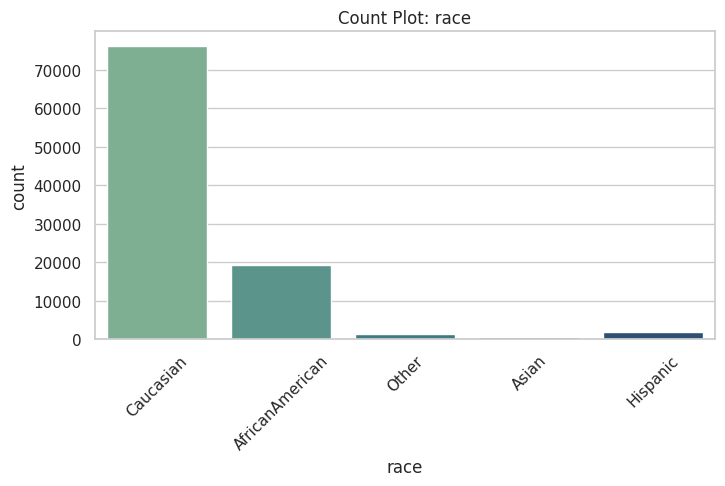

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


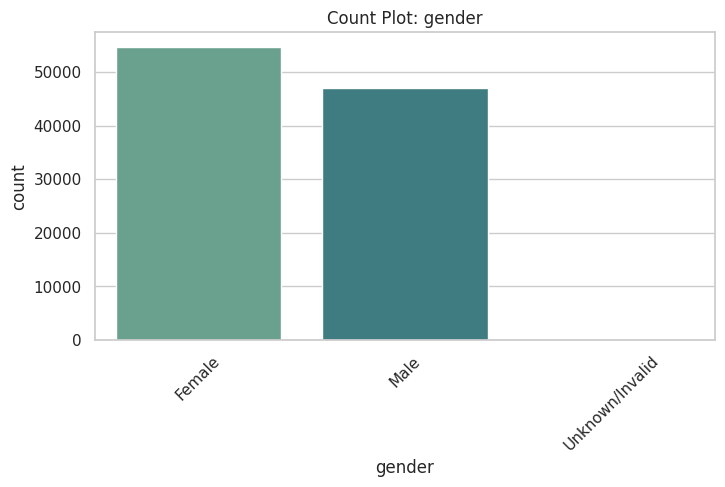

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


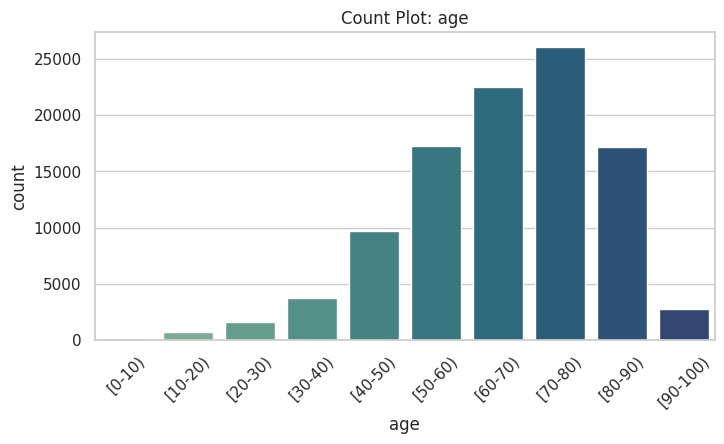

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


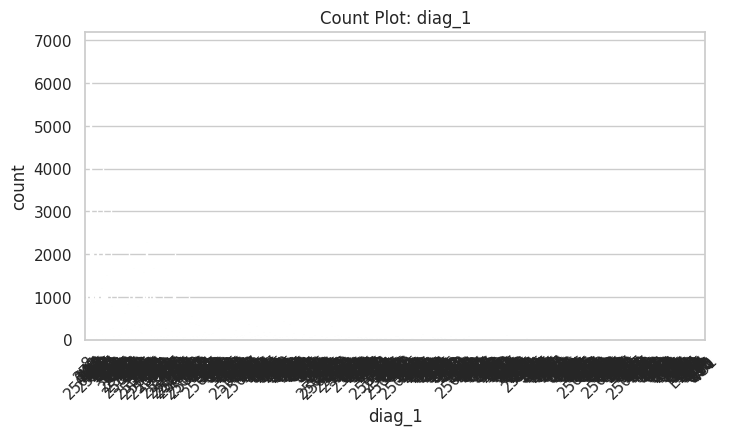

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


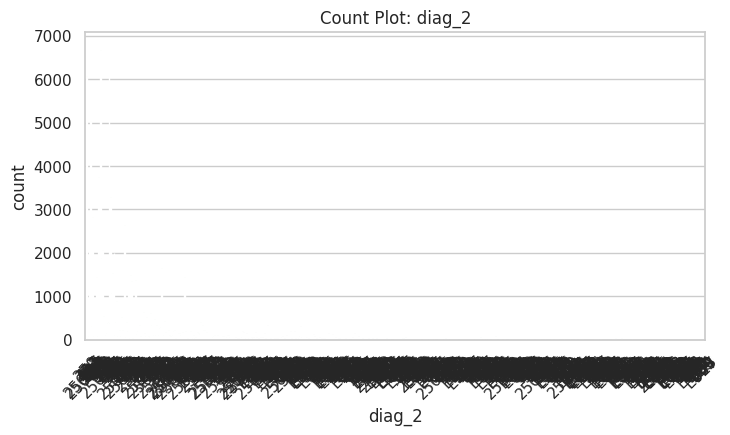

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


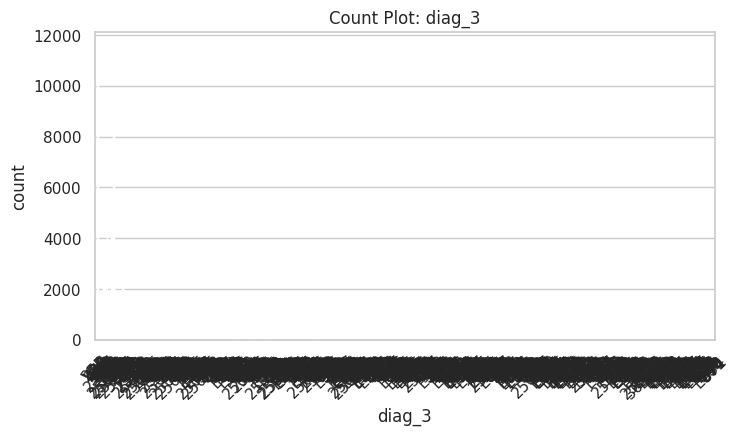

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


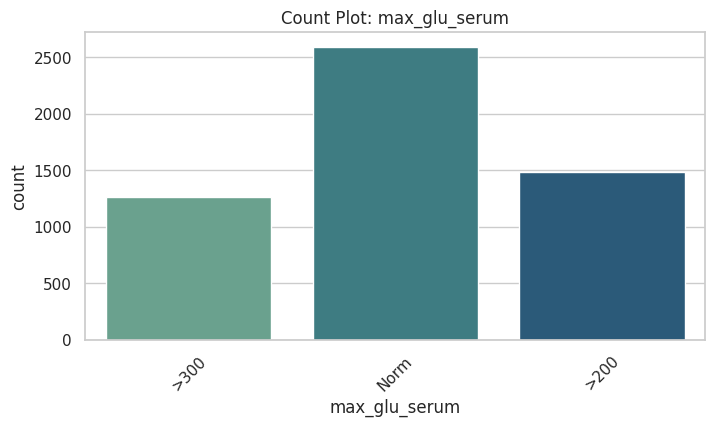

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


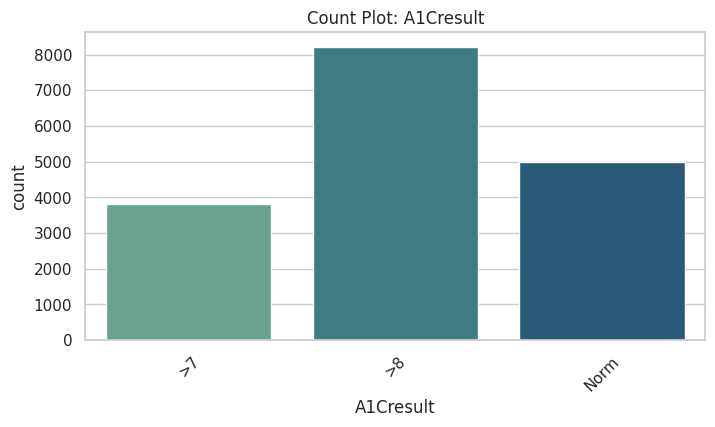

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


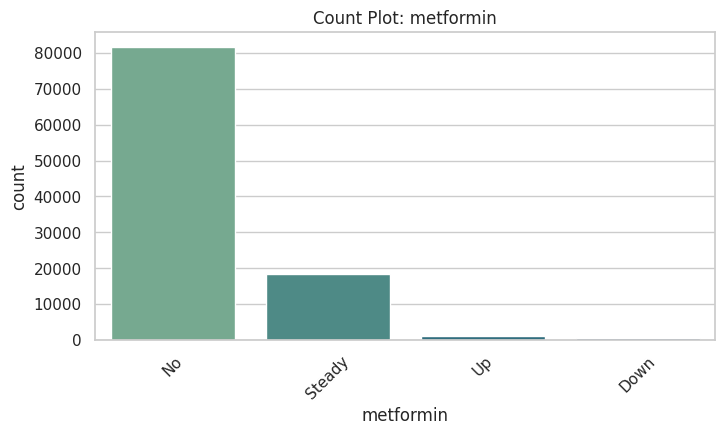

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


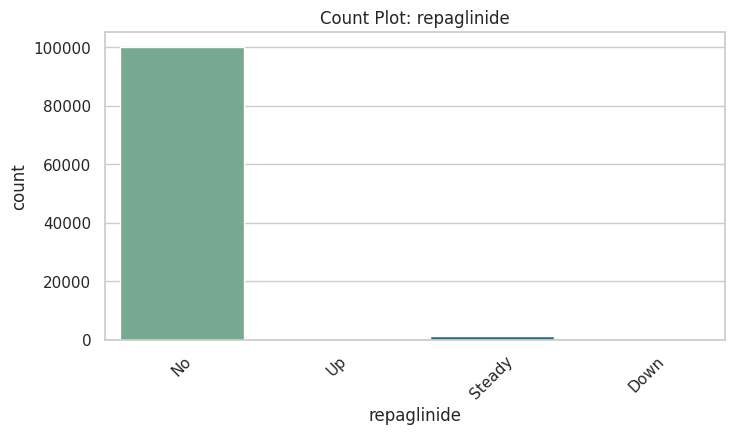

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


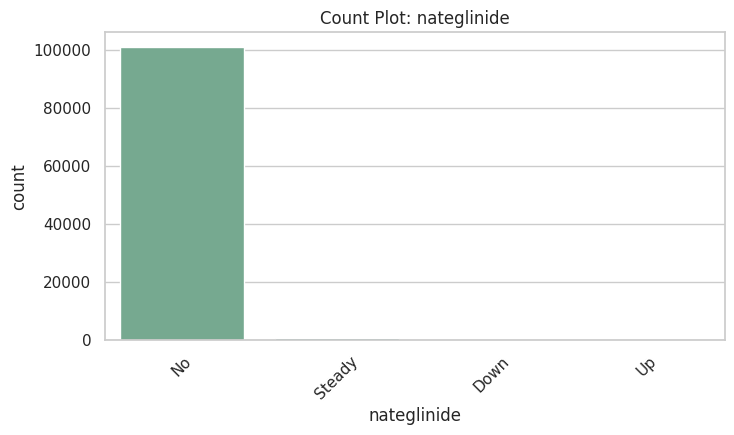

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


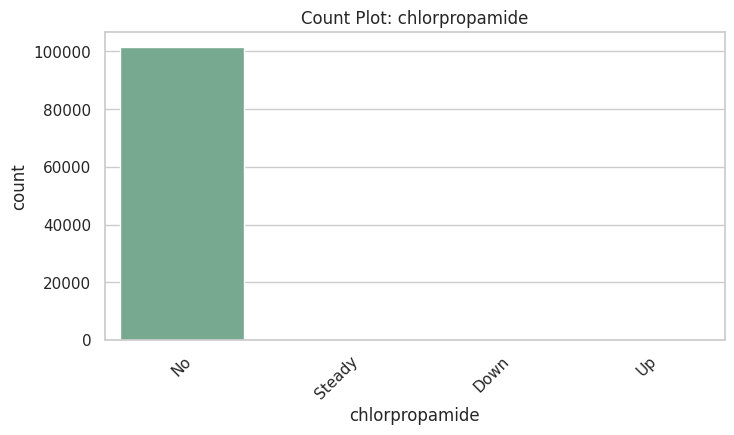

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


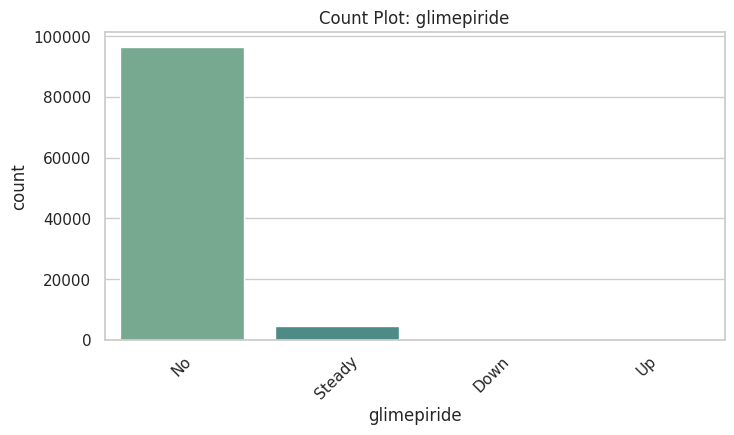

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


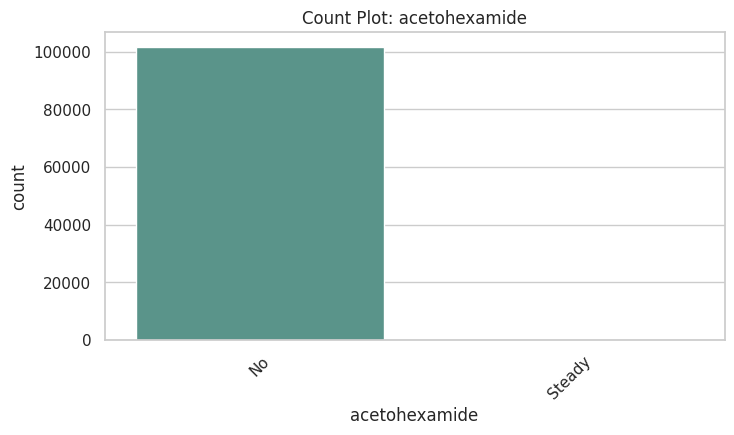

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


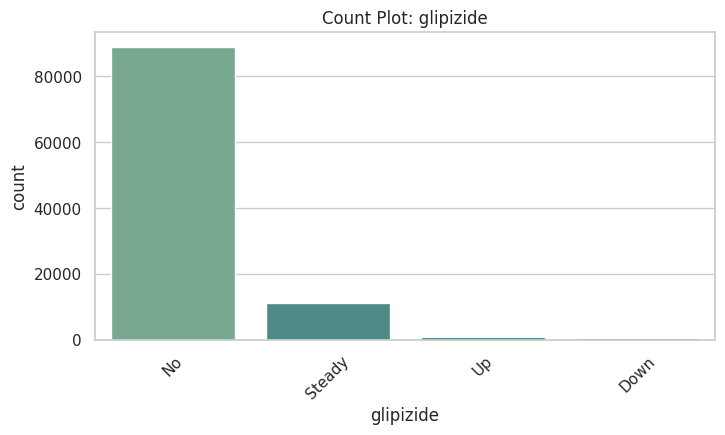

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


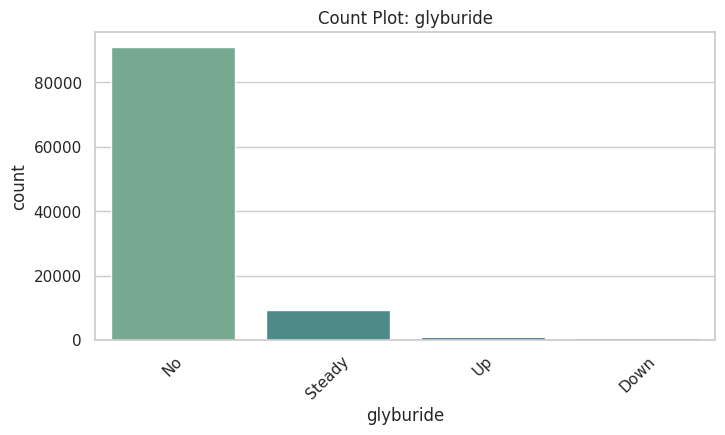

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


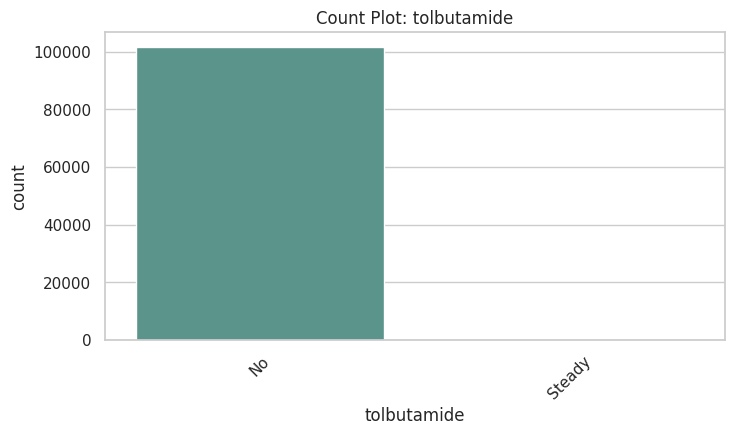

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


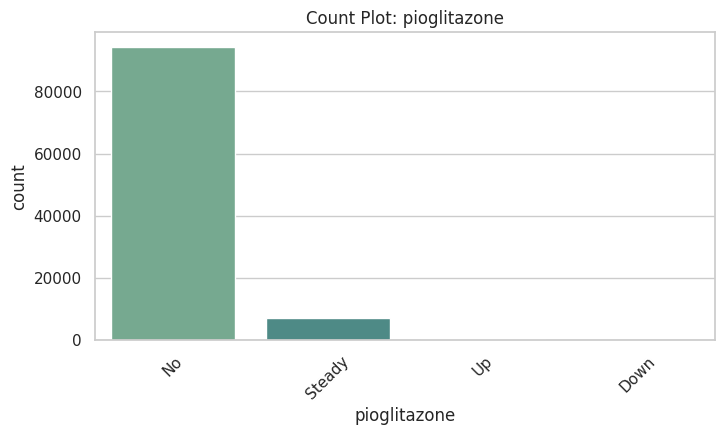

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


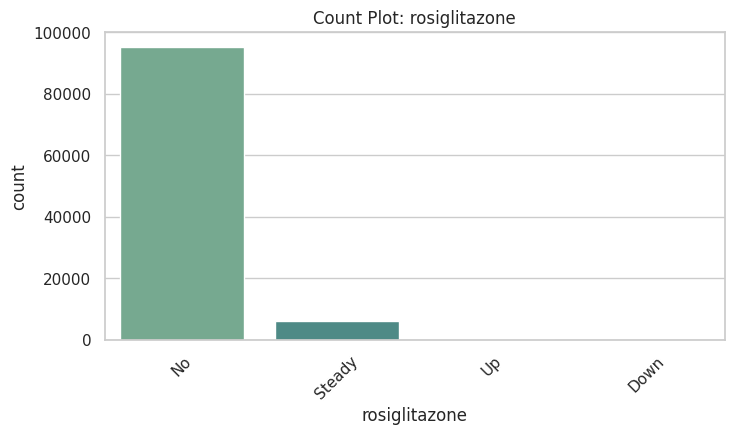

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


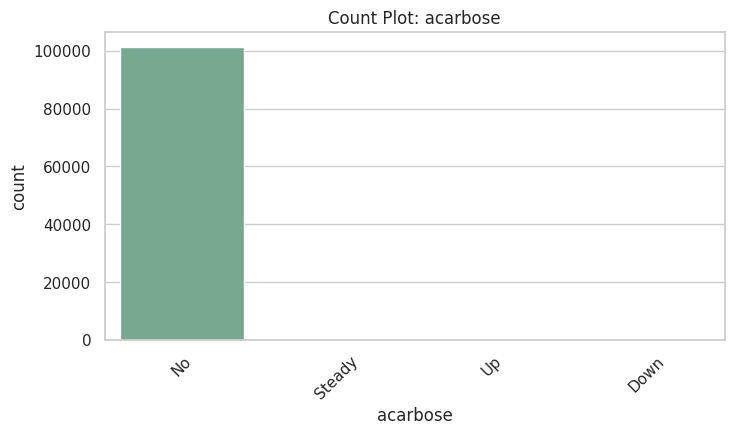

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


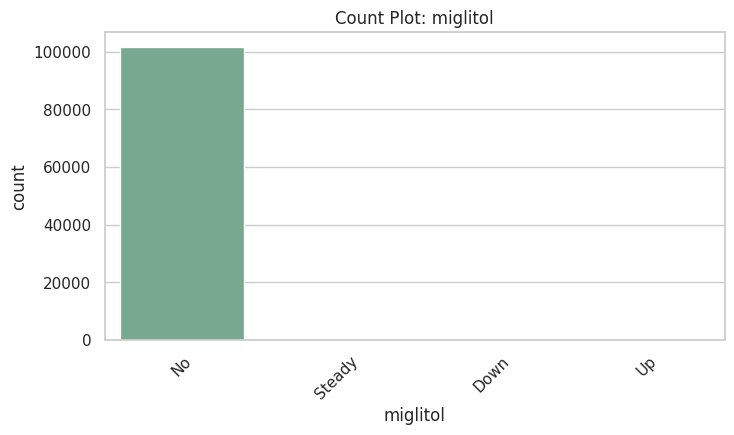

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


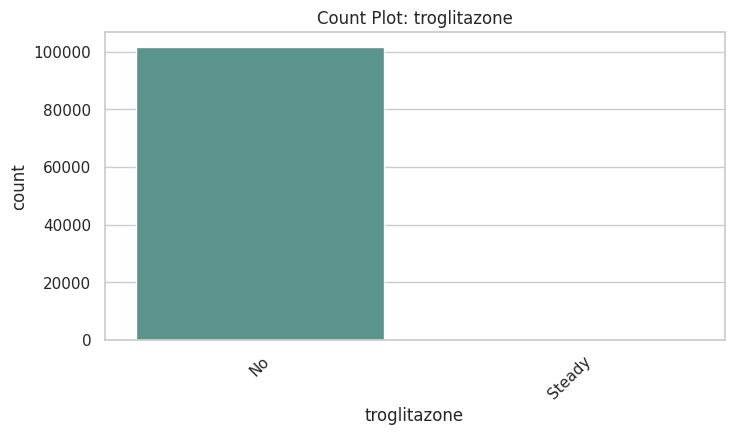

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


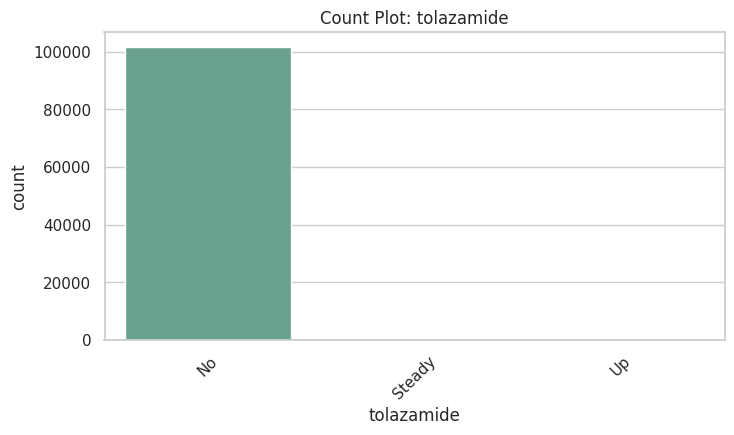

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


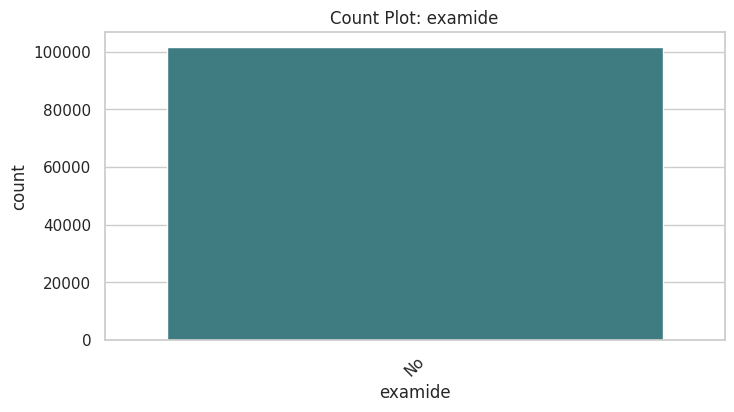

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


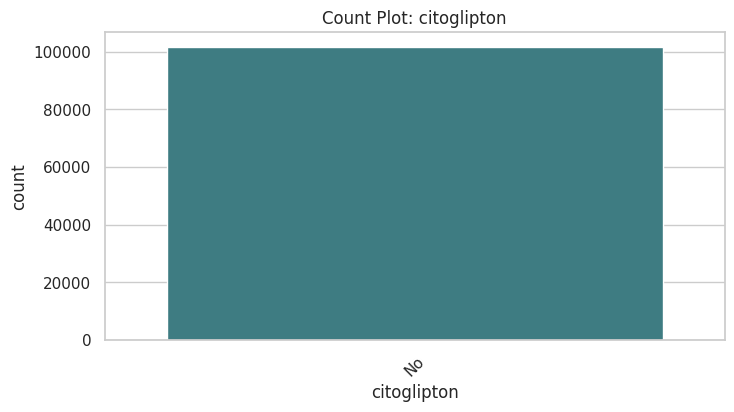

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


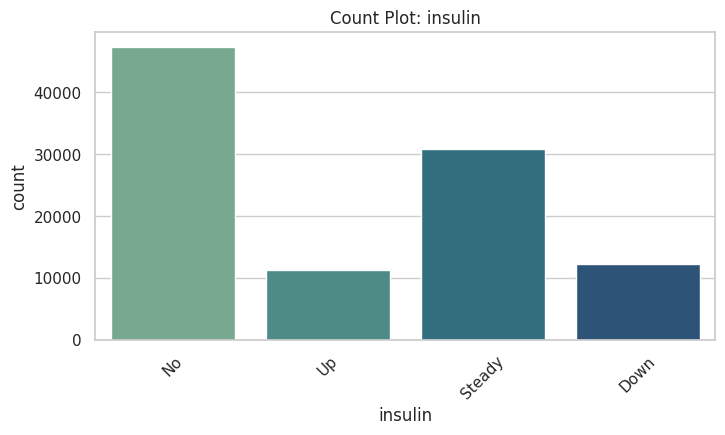

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


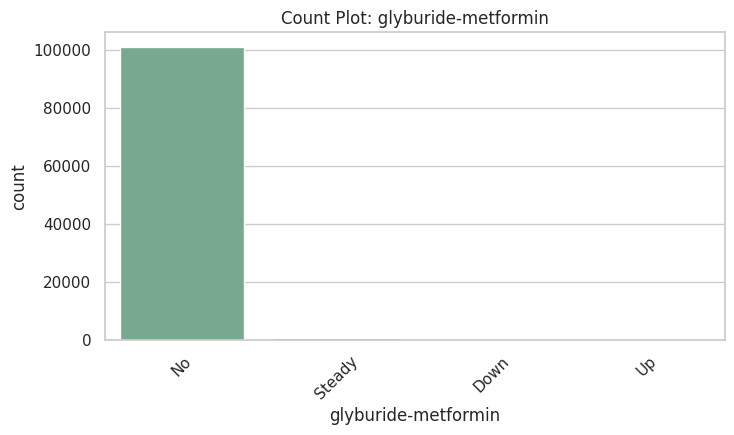

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


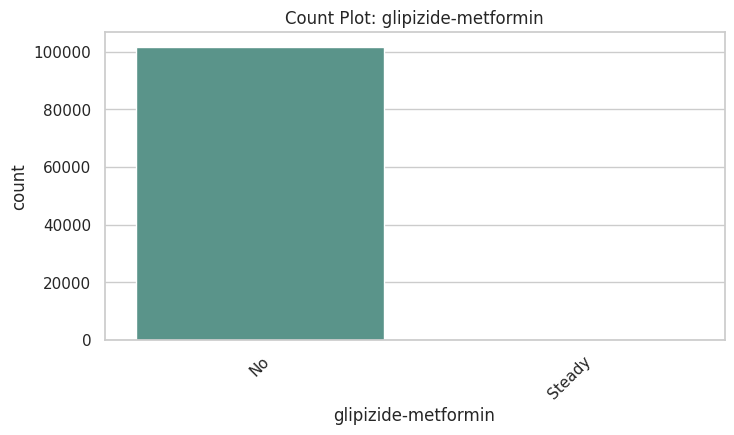

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


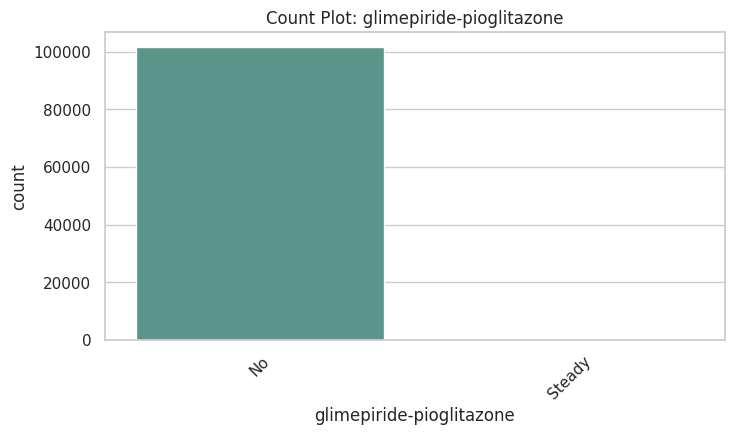

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


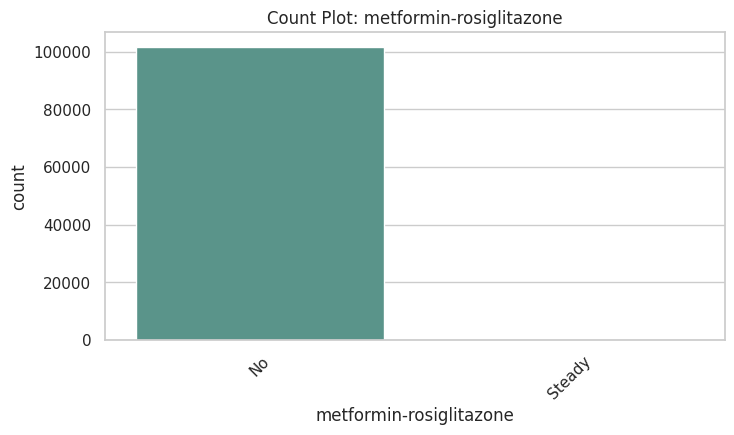

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


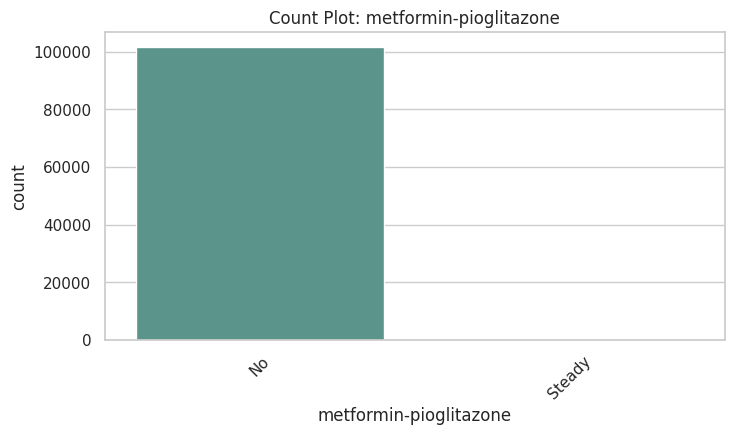

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


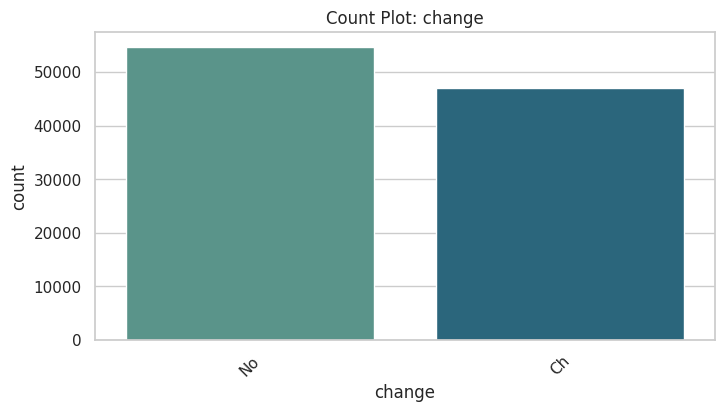

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


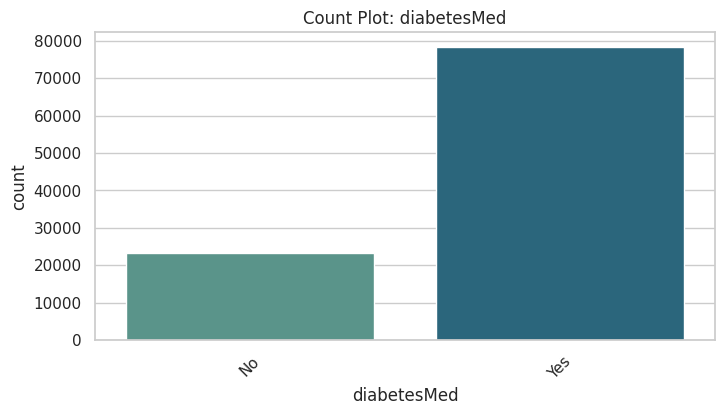

/tmp/ipykernel_448/3665080562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="crest")


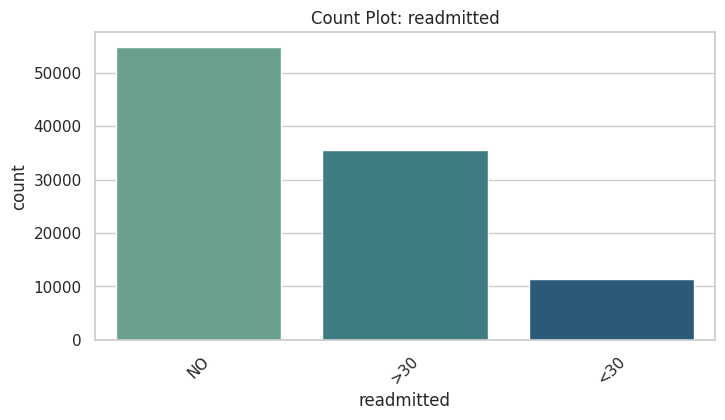

In [22]:
#Count Plots for Categorical Variables

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, palette="crest")
    plt.xticks(rotation=45)
    plt.title(f"Count Plot: {col}")
    plt.show()

Feature vs Target Relationship

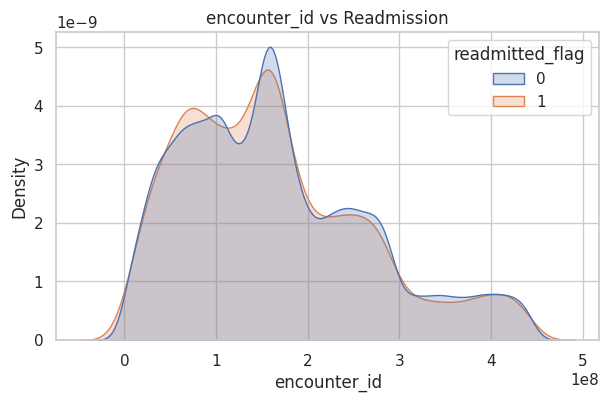

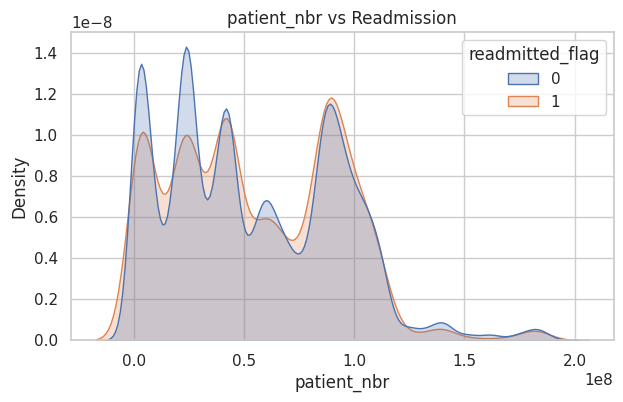

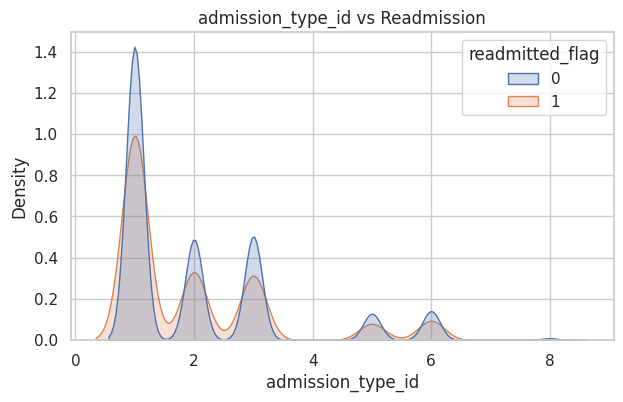

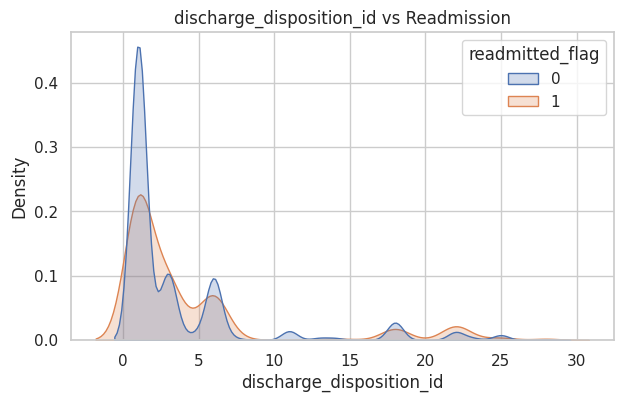

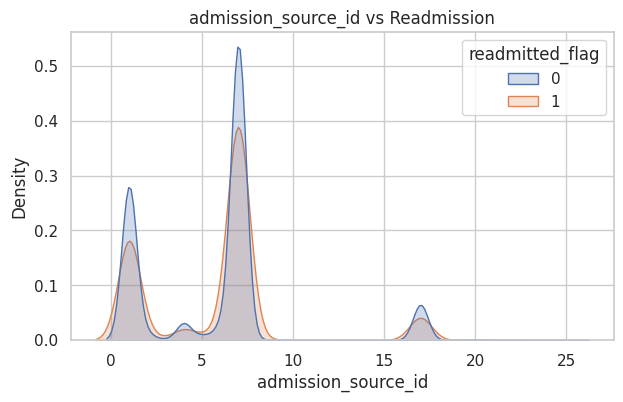

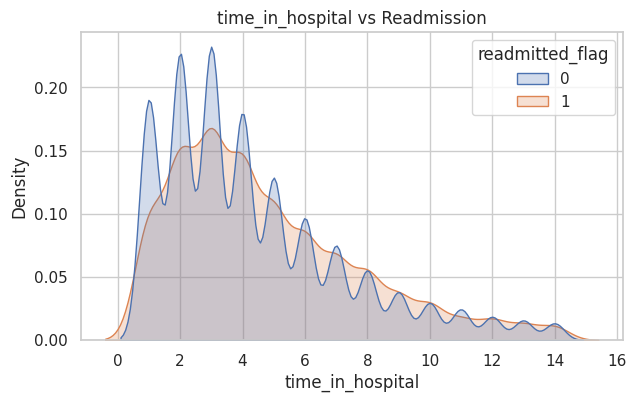

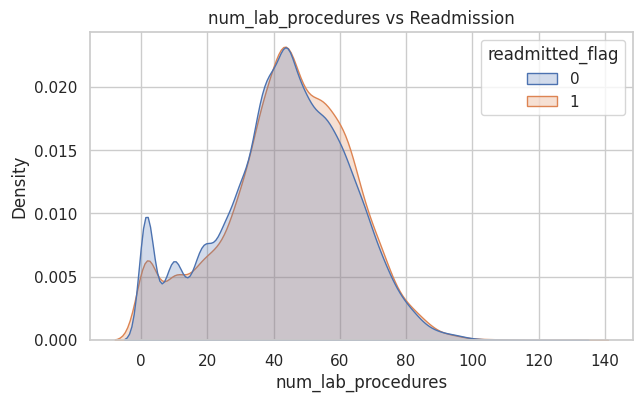

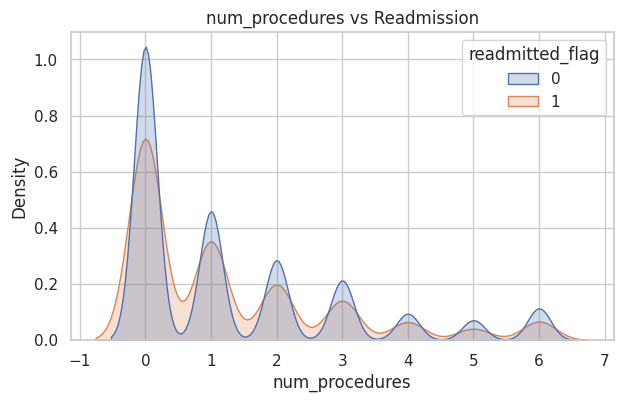

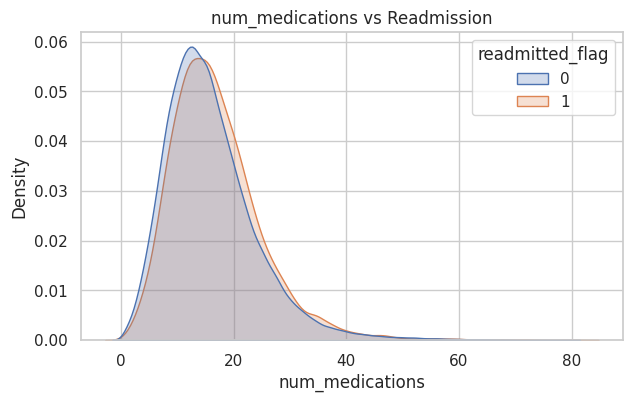

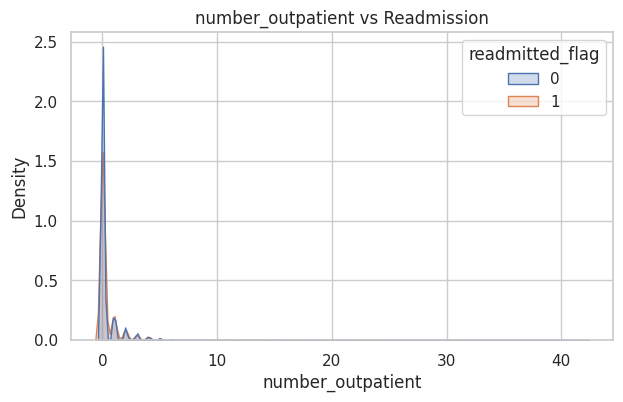

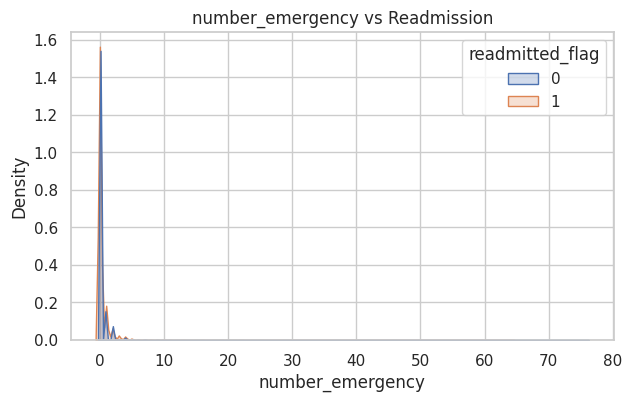

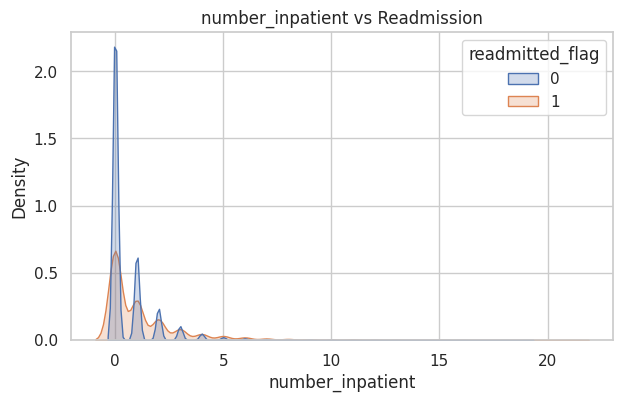

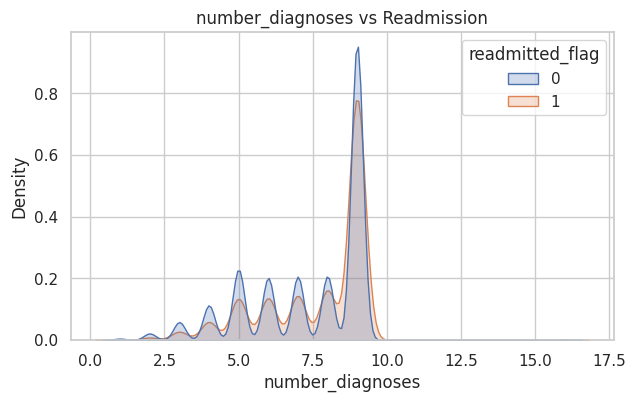

In [23]:
#Numeric vs Target

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df, x=col, hue="readmitted_flag", fill=True, common_norm=False)
    plt.title(f"{col} vs Readmission")
    plt.show()

<Figure size 800x400 with 0 Axes>

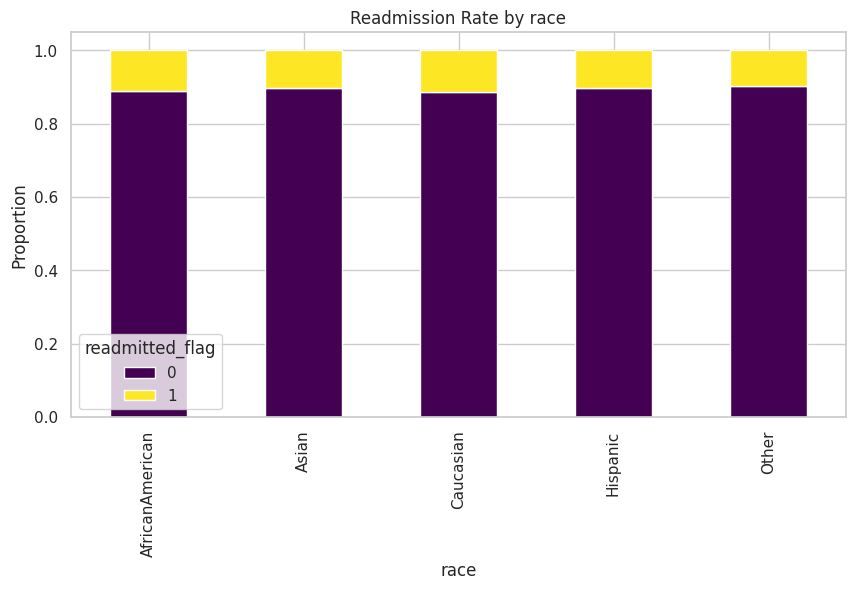

<Figure size 800x400 with 0 Axes>

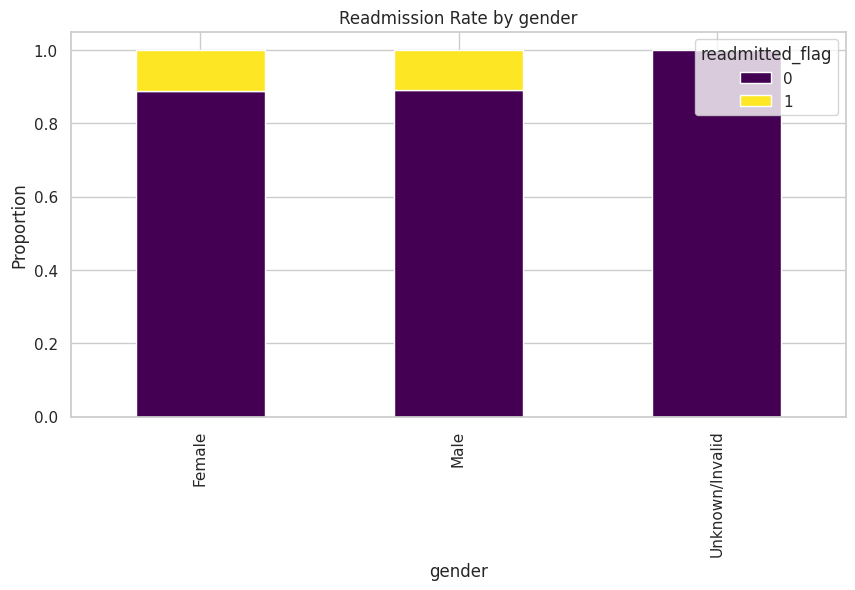

<Figure size 800x400 with 0 Axes>

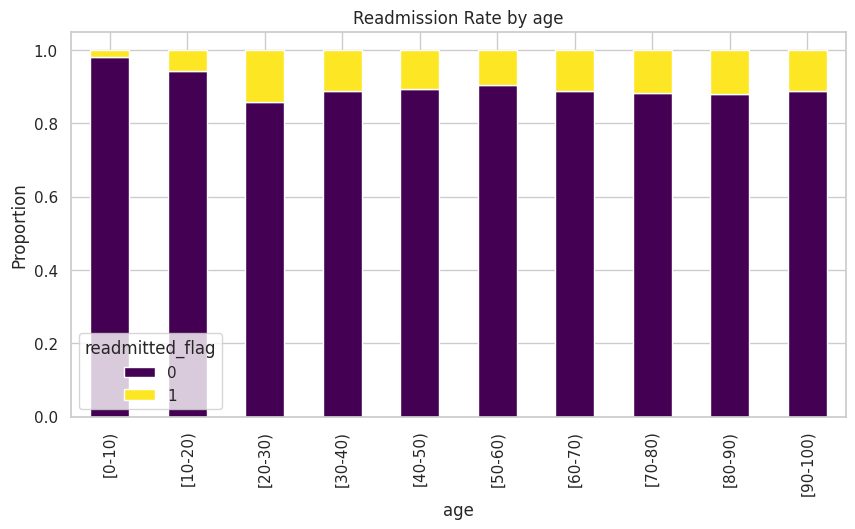

<Figure size 800x400 with 0 Axes>

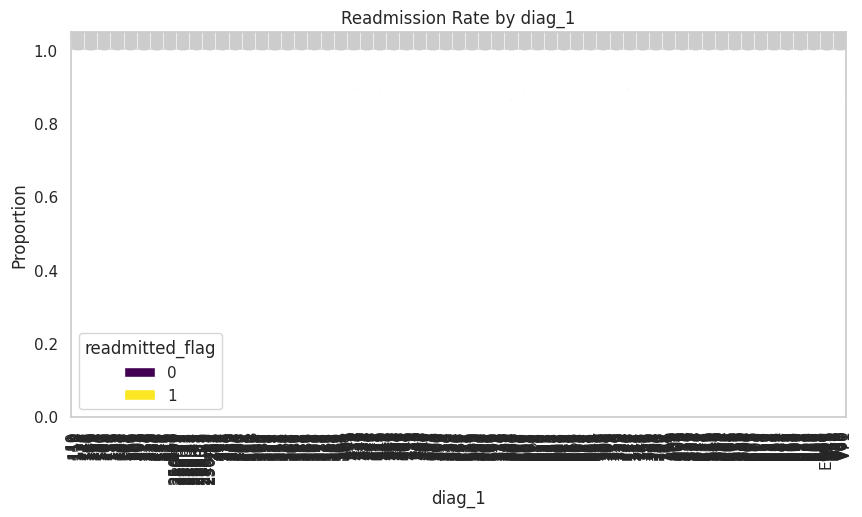

<Figure size 800x400 with 0 Axes>

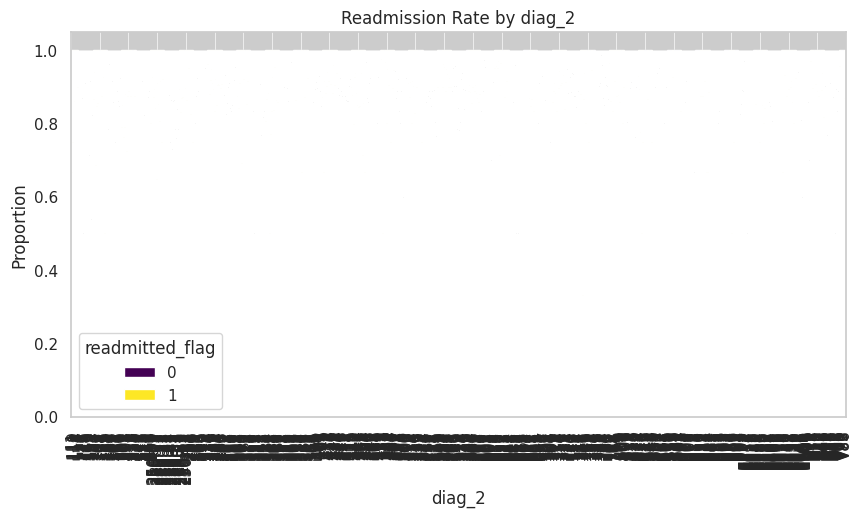

<Figure size 800x400 with 0 Axes>

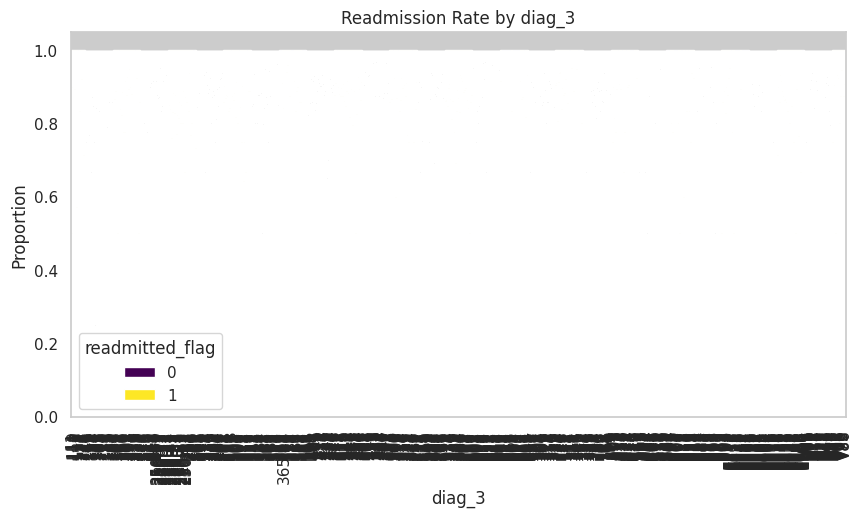

<Figure size 800x400 with 0 Axes>

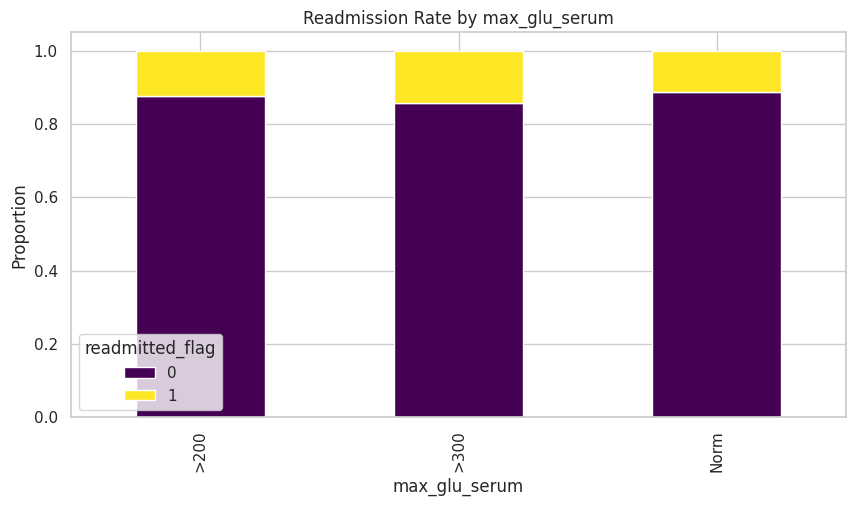

<Figure size 800x400 with 0 Axes>

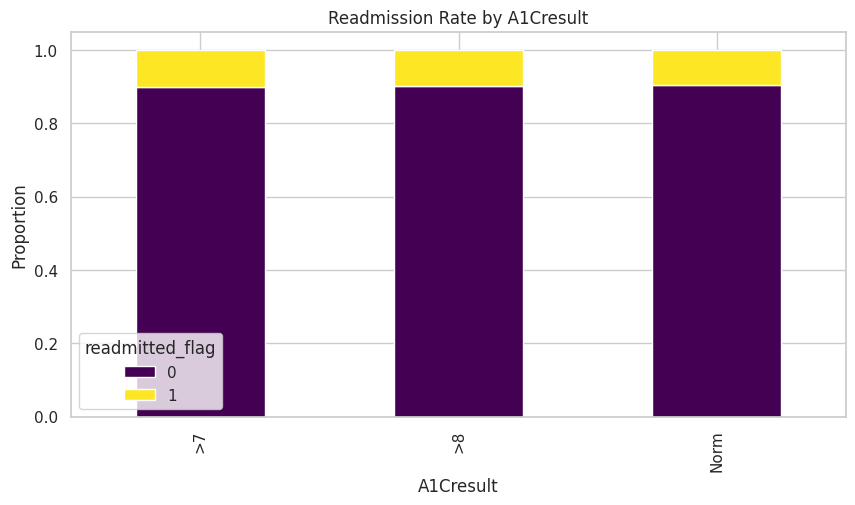

<Figure size 800x400 with 0 Axes>

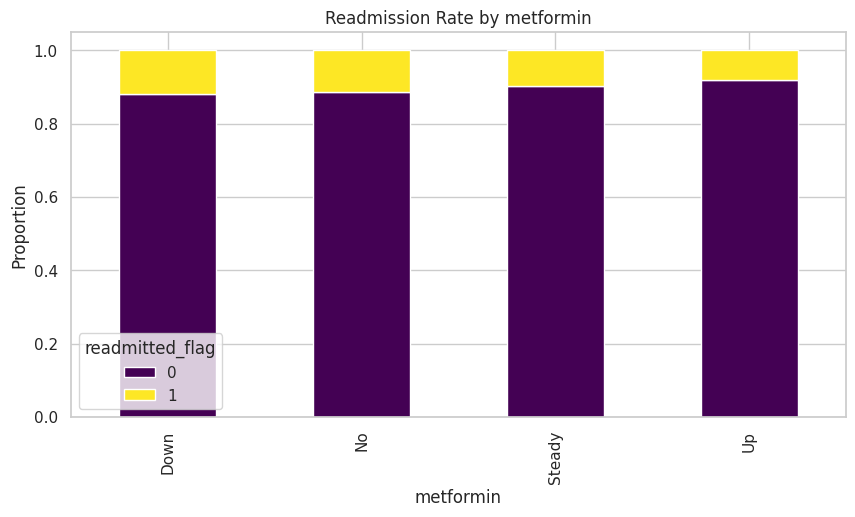

<Figure size 800x400 with 0 Axes>

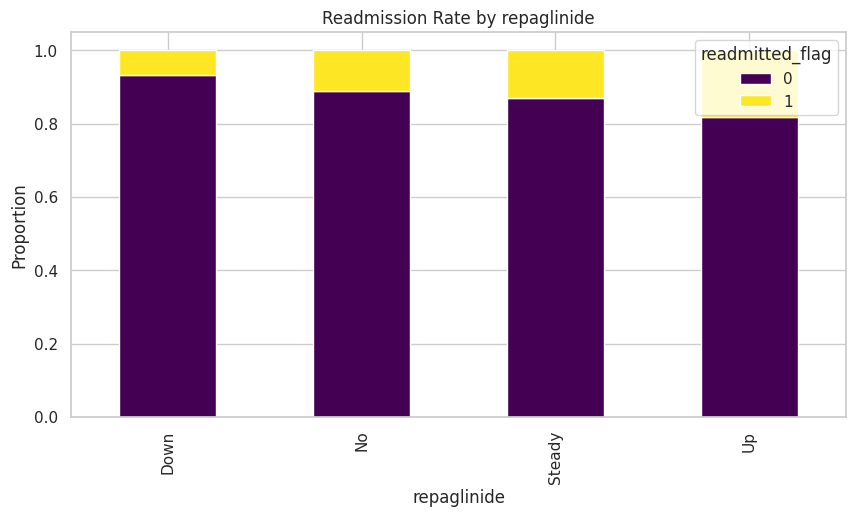

<Figure size 800x400 with 0 Axes>

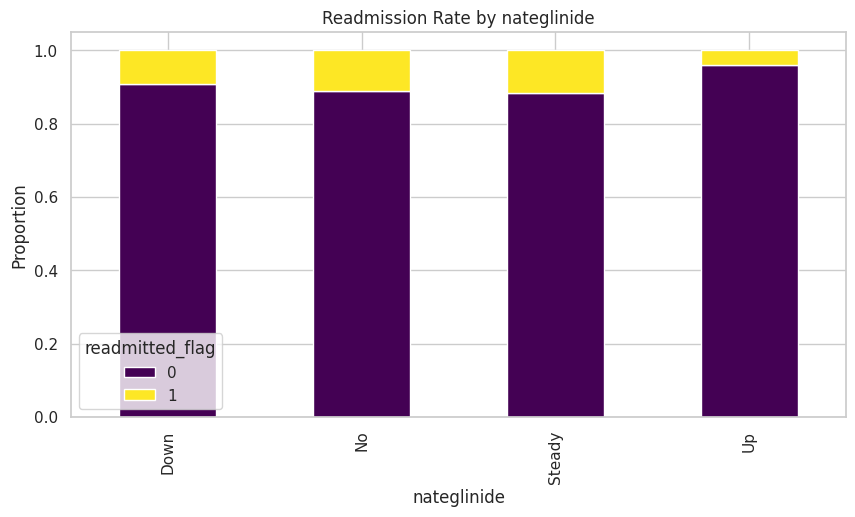

<Figure size 800x400 with 0 Axes>

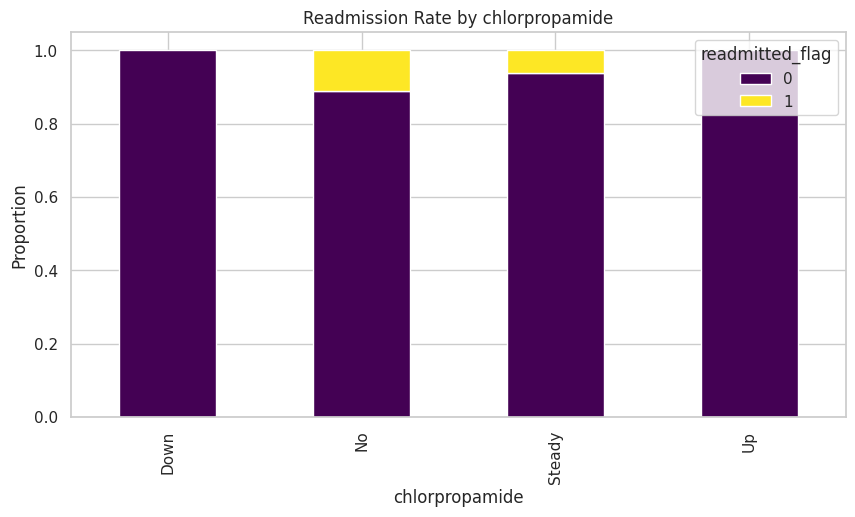

<Figure size 800x400 with 0 Axes>

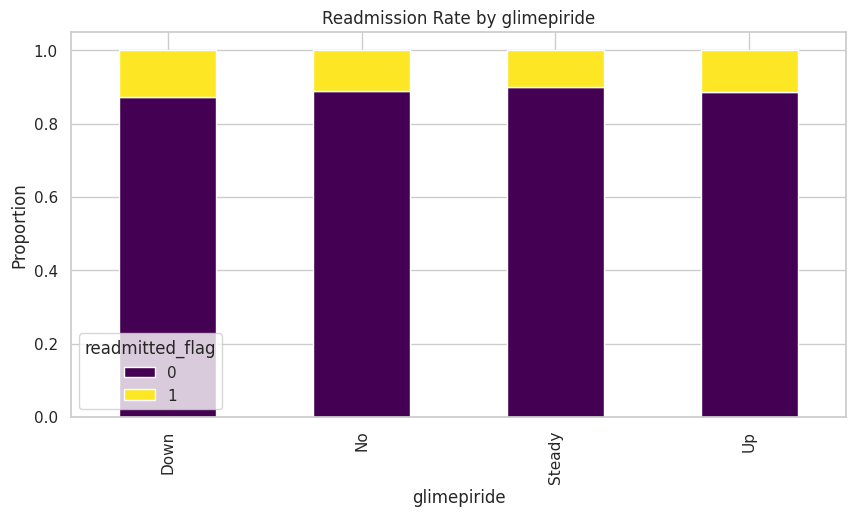

<Figure size 800x400 with 0 Axes>

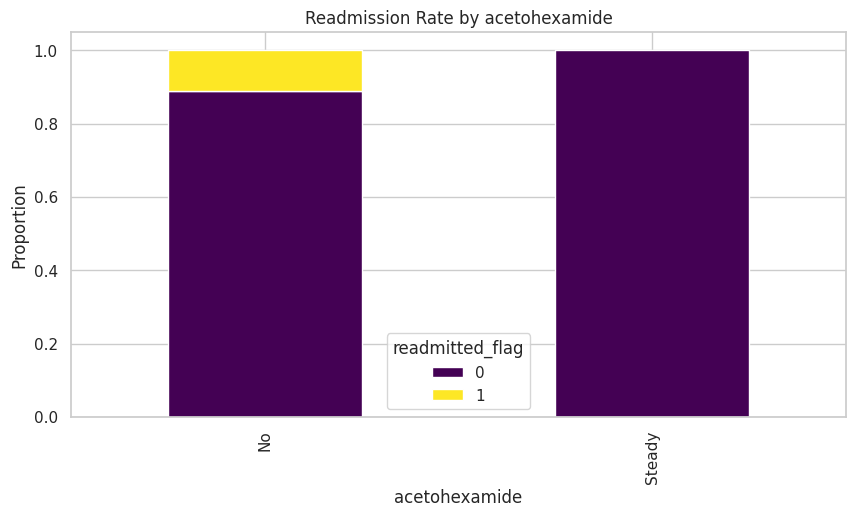

<Figure size 800x400 with 0 Axes>

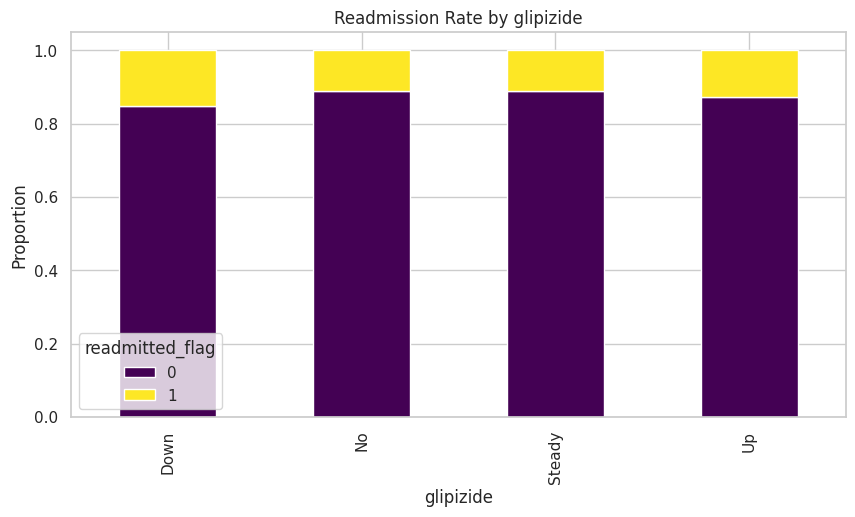

<Figure size 800x400 with 0 Axes>

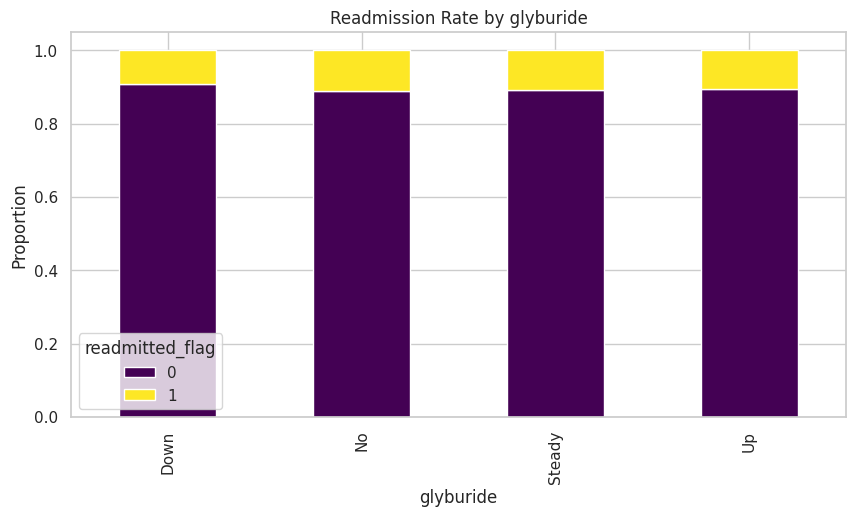

<Figure size 800x400 with 0 Axes>

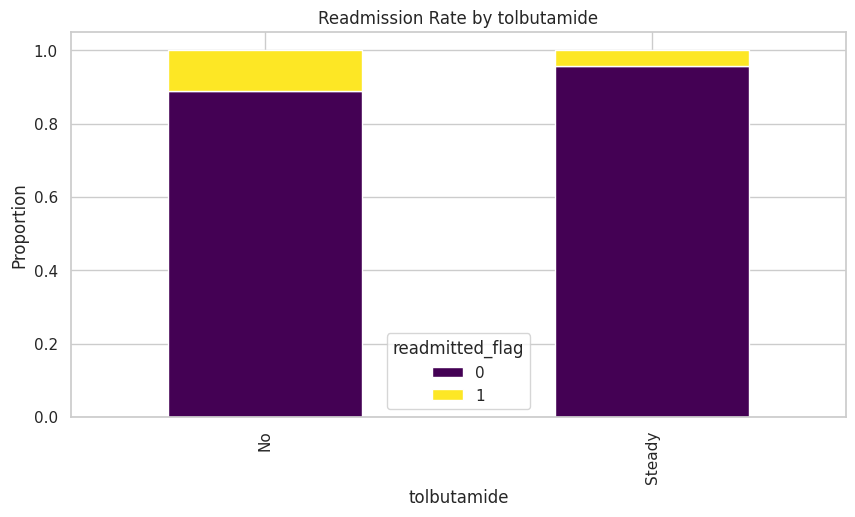

<Figure size 800x400 with 0 Axes>

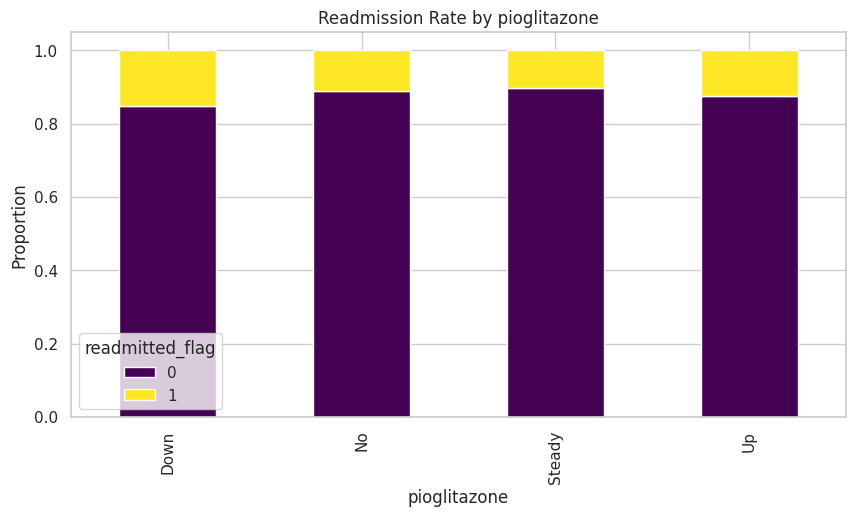

<Figure size 800x400 with 0 Axes>

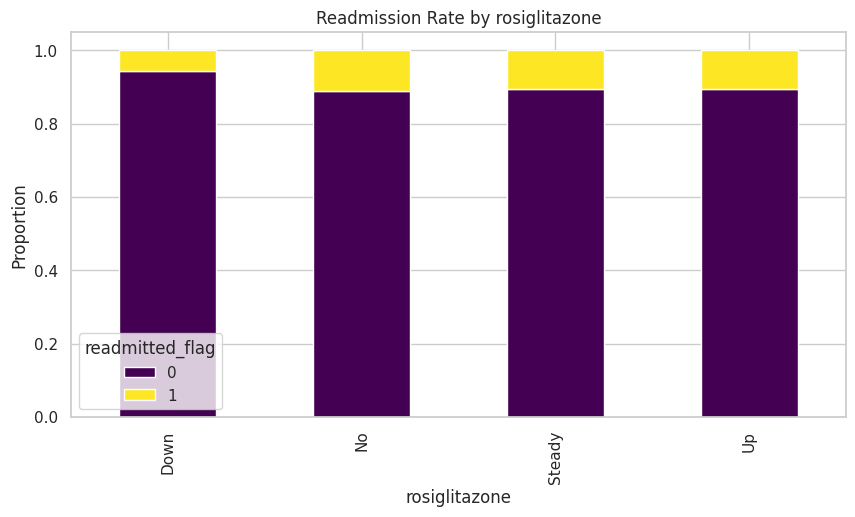

<Figure size 800x400 with 0 Axes>

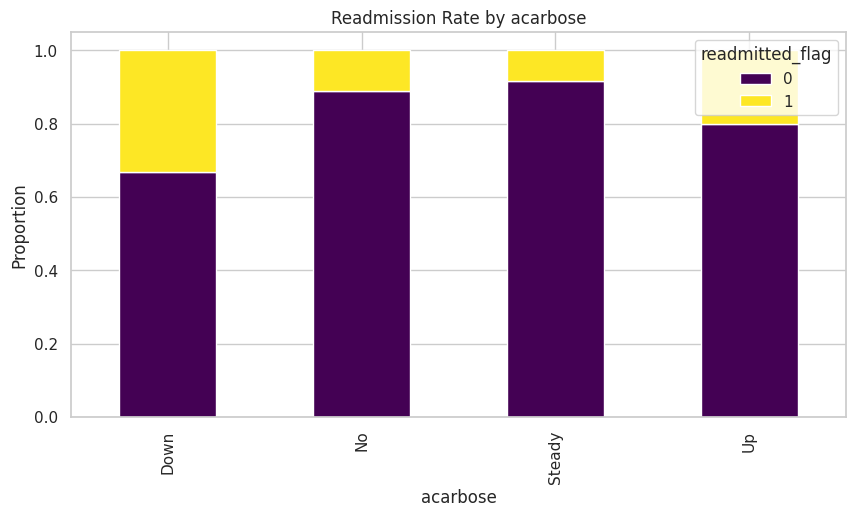

<Figure size 800x400 with 0 Axes>

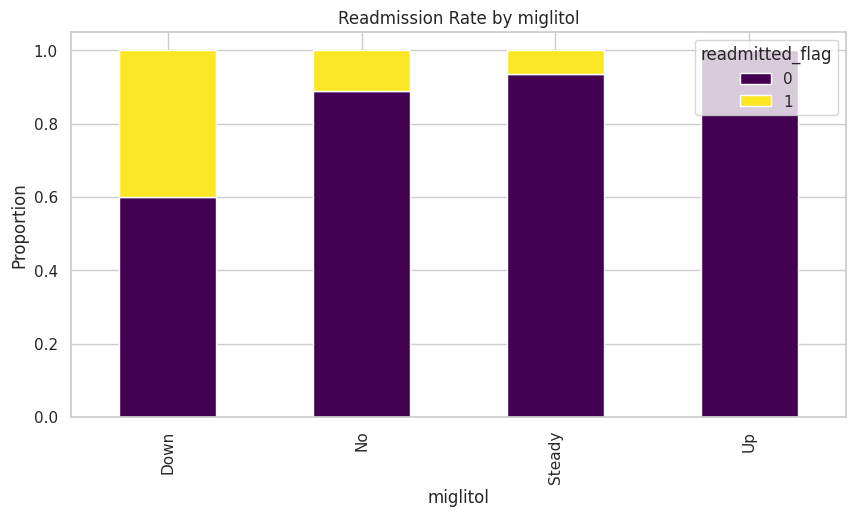

<Figure size 800x400 with 0 Axes>

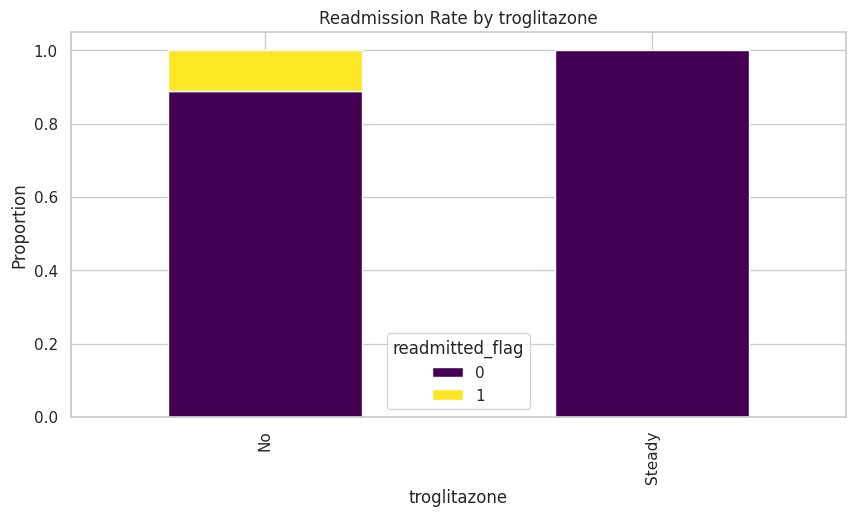

<Figure size 800x400 with 0 Axes>

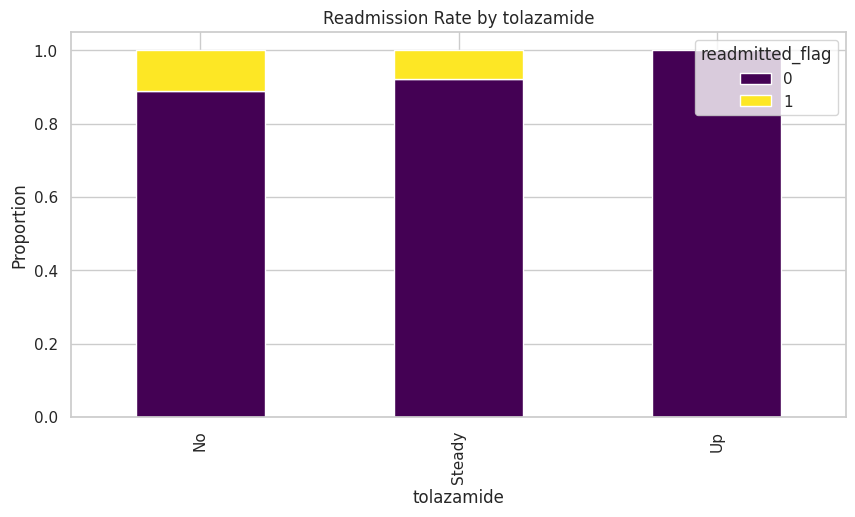

<Figure size 800x400 with 0 Axes>

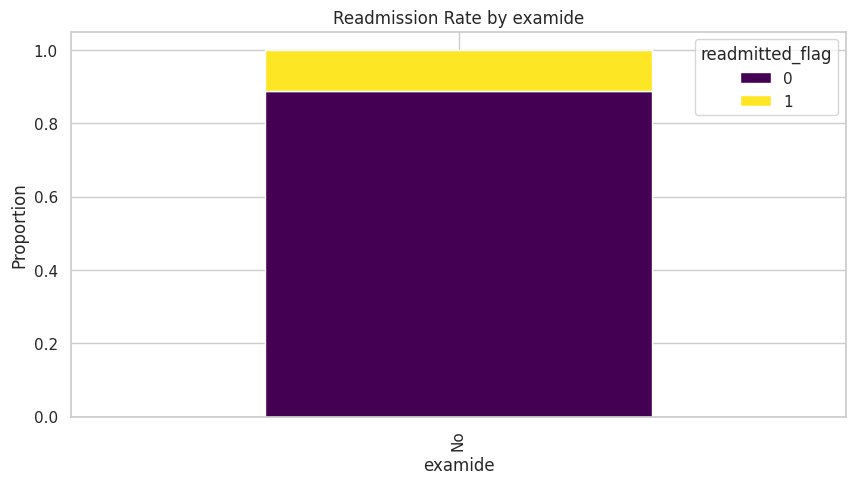

<Figure size 800x400 with 0 Axes>

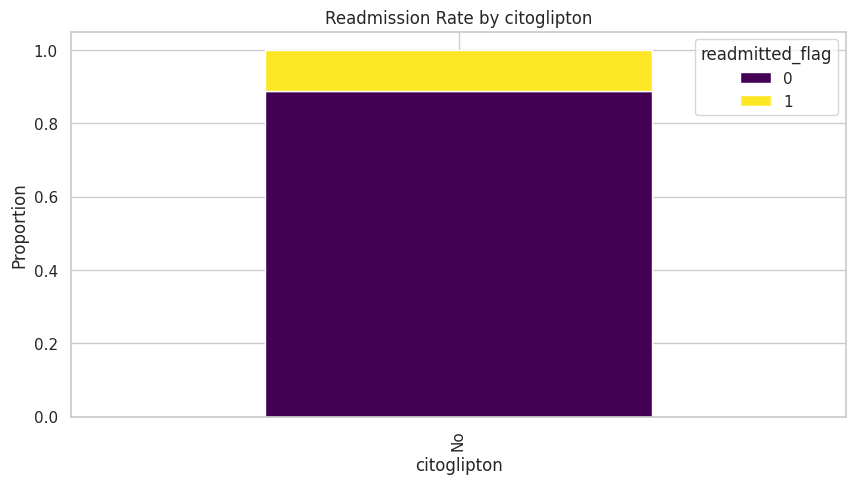

<Figure size 800x400 with 0 Axes>

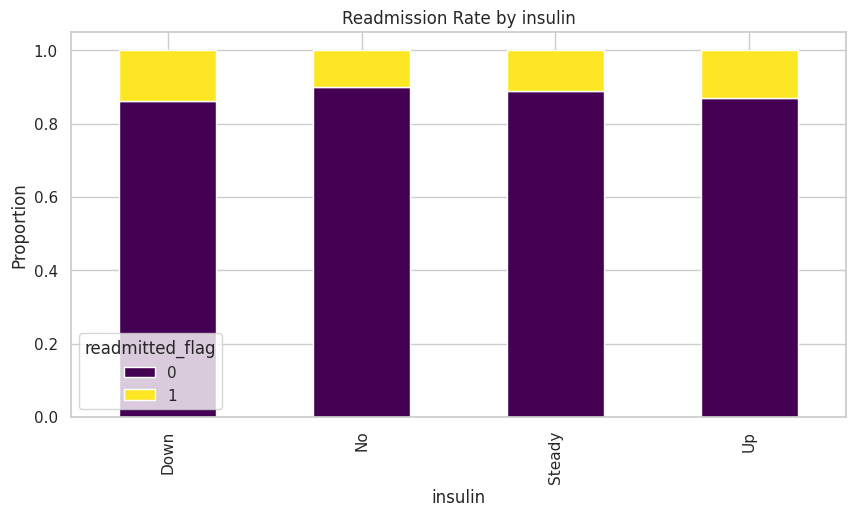

<Figure size 800x400 with 0 Axes>

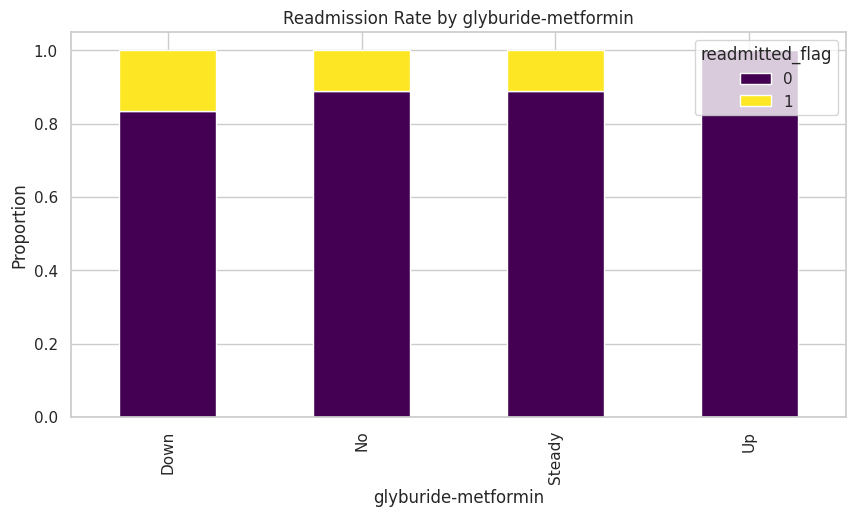

<Figure size 800x400 with 0 Axes>

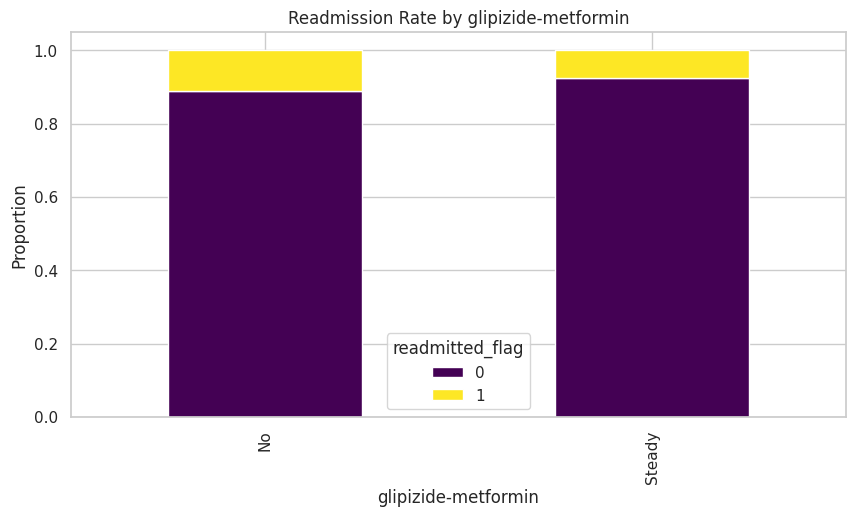

<Figure size 800x400 with 0 Axes>

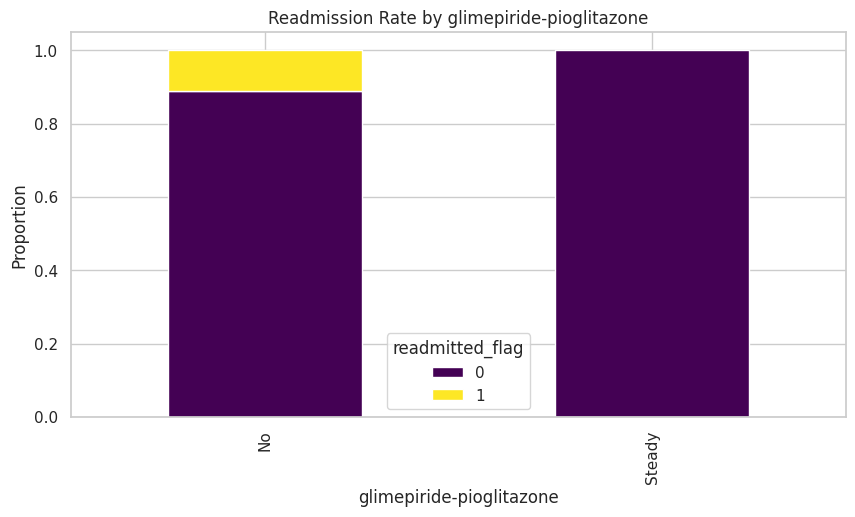

<Figure size 800x400 with 0 Axes>

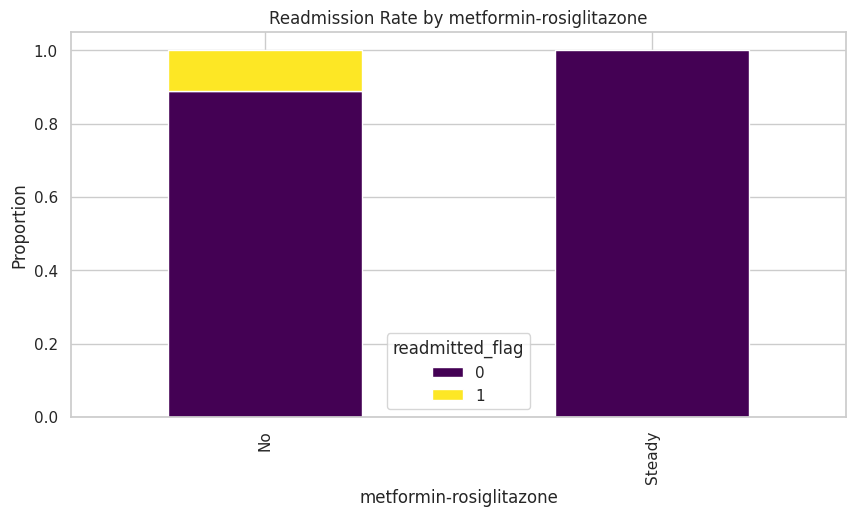

<Figure size 800x400 with 0 Axes>

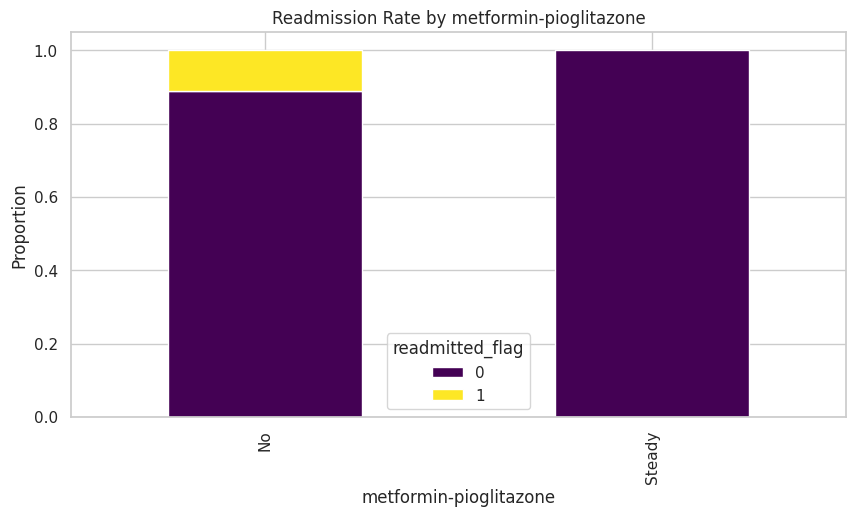

<Figure size 800x400 with 0 Axes>

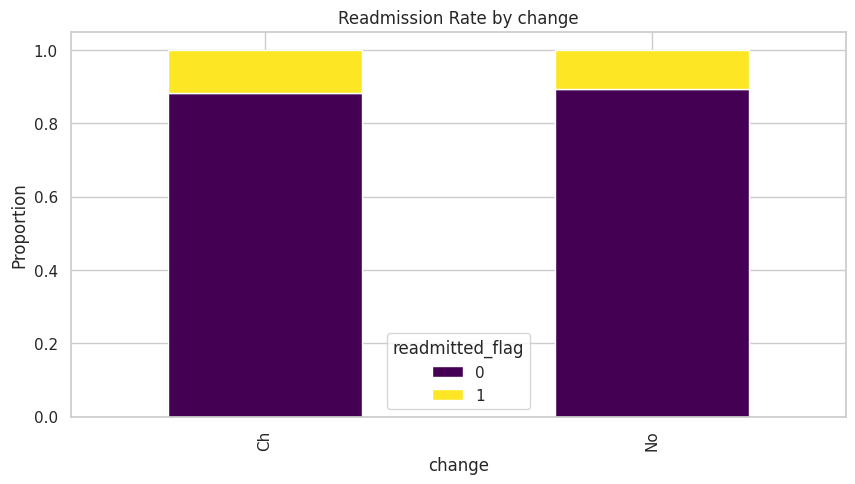

<Figure size 800x400 with 0 Axes>

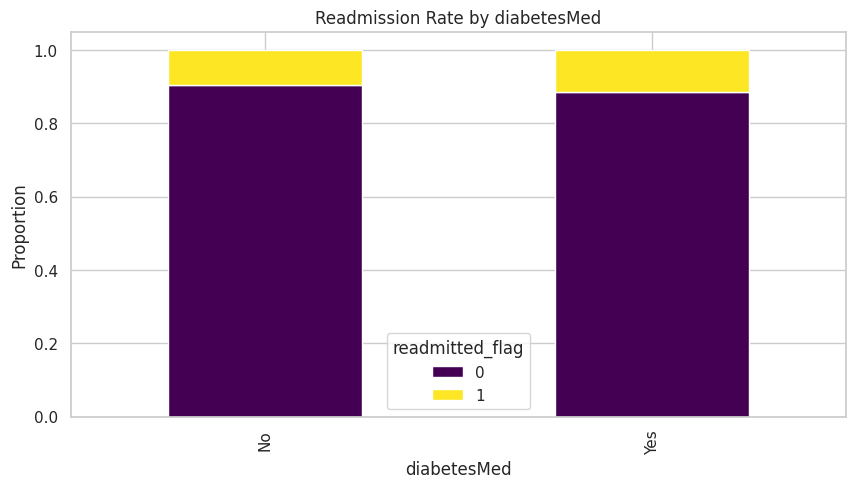

<Figure size 800x400 with 0 Axes>

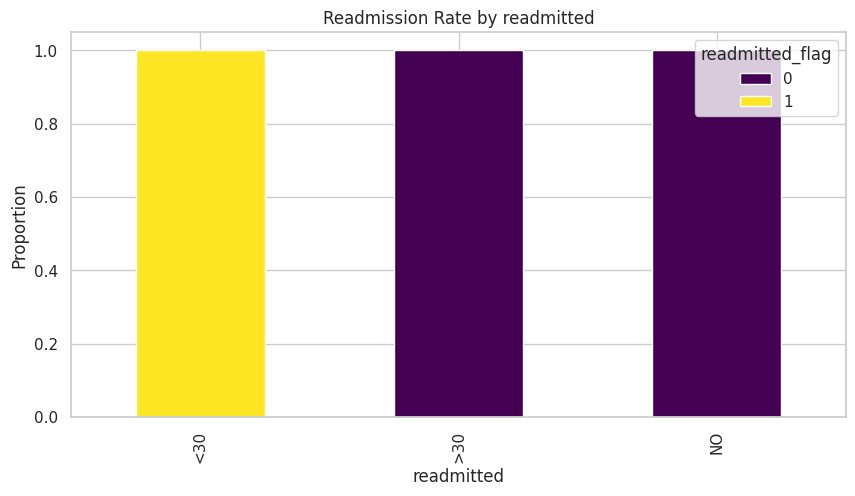

In [24]:
#Categorical vs Traget

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    ct = pd.crosstab(df[col], df['readmitted_flag'], normalize='index')
    ct.plot(kind='bar', stacked=True, colormap='viridis')
    plt.title(f"Readmission Rate by {col}")
    plt.ylabel("Proportion")
    plt.show()

Correlation Analysis

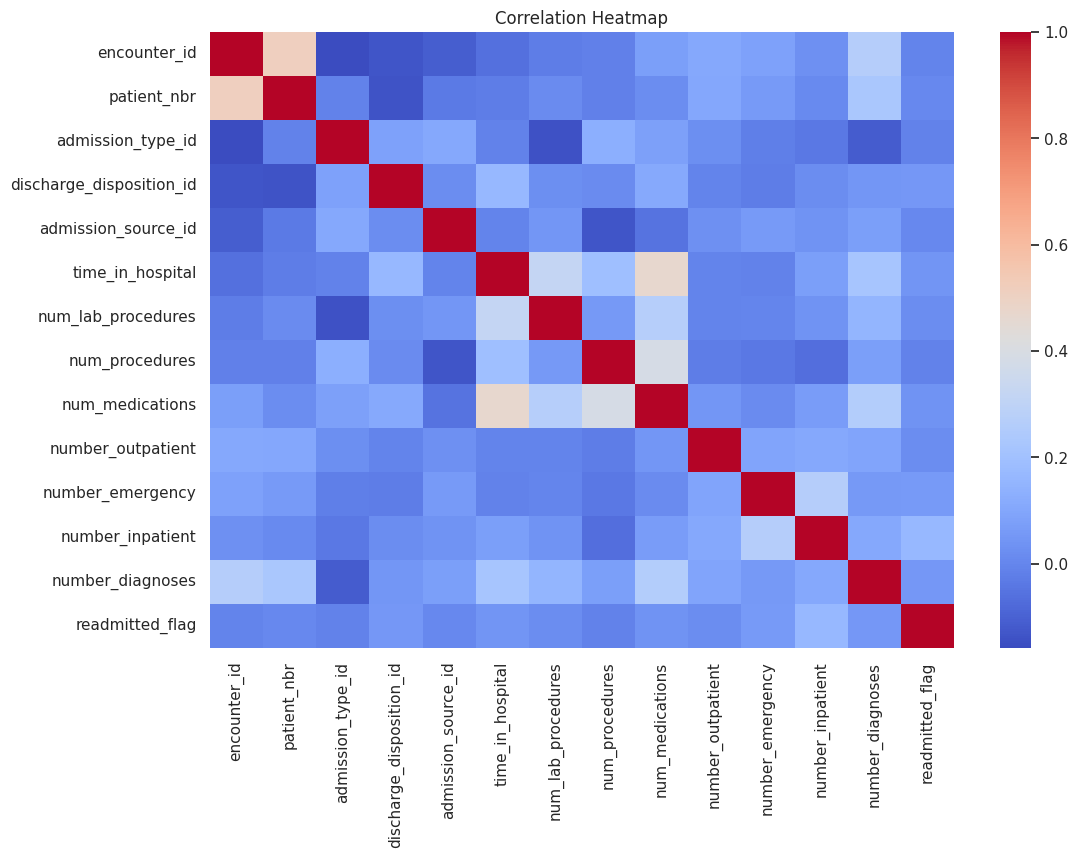

In [25]:
#Correlation Matrix

corr = df[numeric_cols + ['readmitted_flag']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
plt.savefig("results/charts/eda_plotname.png", dpi=150)

<Figure size 1000x500 with 0 Axes>

In [31]:
# Save a local copy of ALL figures
!zip -r eda_charts.zip results/charts
from google.colab import files
files.download("eda_charts.zip")

  adding: results/charts/ (stored 0%)
  adding: results/charts/.gitkeep (stored 0%)
  adding: results/charts/eda_plotname.png (deflated 96%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Key EDA Insights

- **Readmission rate** is low (~X%), confirming significant class imbalance  
- Patients with higher **prior utilization** (ER visits, inpatient visits) show higher readmission risk  
- Certain **discharge dispositions** show elevated readmission probability  
- Higher **medication burden** correlates with higher risk  
- **HbA1c scores** show meaningful separation between readmitted vs not  
- Some ICD‑9 diagnosis groups appear more at risk than others  
- Several numeric variables show skew and may benefit from scaling  

These insights directly influenced feature engineering and model selection in subsequent phases.